# **Capstone Model**

# **Data Loading, EDA, Understanding**

In [ ]:
DATA_FILE =  "gt-framework-synth.xlsx"

In [ ]:
#import as needed
import pandas as pd
import numpy as np

In [ ]:
sheets = pd.read_excel(DATA_FILE, sheet_name=None)

In [ ]:
sheets

{'DATA_DICTIONARY':                  Sheet name  \
 0              A_brand_kpis   
 1   B_competitive_benchmark   
 2                C_personas   
 3      D_platform_inventory   
 4                 E_reg_fit   
 5                F_bop_risk   
 6     GT_Series_Assumptions   
 7                I_team_tam   
 8    J_competitor_economics   
 9       Synthetic_BOM_Proxy   
 10     Unit_Economics_Model   
 11         O_stage_gate_log   
 
                                               Purpose  \
 0                Brand objectives + weighted KPI tree   
 1   Competitive GT participation/activation benchm...   
 2       Customer racing personas + preference weights   
 3   Candidate production platforms (GM + comparato...   
 4   Platform-to-GT feasibility + change burden + c...   
 5   Performance balancing (BoP-like) risk + adjust...   
 6   Anonymized GT-series tier definitions + constr...   
 7   Market size proxies by series & region (synthe...   
 8            Competitor economics proxie

In [ ]:
sheets


{'DATA_DICTIONARY':                  Sheet name  \
 0              A_brand_kpis   
 1   B_competitive_benchmark   
 2                C_personas   
 3      D_platform_inventory   
 4                 E_reg_fit   
 5                F_bop_risk   
 6     GT_Series_Assumptions   
 7                I_team_tam   
 8    J_competitor_economics   
 9       Synthetic_BOM_Proxy   
 10     Unit_Economics_Model   
 11         O_stage_gate_log   
 
                                               Purpose  \
 0                Brand objectives + weighted KPI tree   
 1   Competitive GT participation/activation benchm...   
 2       Customer racing personas + preference weights   
 3   Candidate production platforms (GM + comparato...   
 4   Platform-to-GT feasibility + change burden + c...   
 5   Performance balancing (BoP-like) risk + adjust...   
 6   Anonymized GT-series tier definitions + constr...   
 7   Market size proxies by series & region (synthe...   
 8            Competitor economics proxie

In [ ]:
df_brand_kpis         = sheets["A_brand_kpis"]
df_competitive        = sheets["B_competitive_benchmark"]
df_personas           = sheets["C_personas"]
df_platforms          = sheets["D_platform_inventory"]
df_reg_fit            = sheets["E_reg_fit"]
df_bop_risk           = sheets["F_bop_risk"]
df_gt_assumptions     = sheets["GT_Series_Assumptions"]
df_team_tam           = sheets["I_team_tam"]
df_competitor_econ    = sheets["J_competitor_economics"]
df_bom                = sheets["Synthetic_BOM_Proxy"]
df_unit_economics     = sheets["Unit_Economics_Model"]
df_stage_gate         = sheets["O_stage_gate_log"]

In [ ]:
print('eda: sizes of each sheet within excel')
for sheet_name, df in sheets.items():
    print('')
    print(f"{sheet_name}: {df.shape[0]} rows × {df.shape[1]} cols")

eda: sizes of each sheet within excel

DATA_DICTIONARY: 12 rows × 4 cols

A_brand_kpis: 25 rows × 10 cols

B_competitive_benchmark: 20 rows × 9 cols

C_personas: 5 rows × 16 cols

D_platform_inventory: 10 rows × 15 cols

E_reg_fit: 20 rows × 12 cols

F_bop_risk: 15 rows × 10 cols

GT_Series_Assumptions: 2 rows × 13 cols

I_team_tam: 18 rows × 8 cols

J_competitor_economics: 20 rows × 9 cols

O_stage_gate_log: 6 rows × 7 cols

Synthetic_BOM_Proxy: 160 rows × 10 cols

Unit_Economics_Model: 20 rows × 11 cols


**Gate 0**

As our final output desire is a go / no go decision model based on multiple data points, we first define what the OEM motors definition of success should be.

In this model success is likely defined by _____.


we want to first explore the historical and projected KPIs to understand performance and benchmarking.


In [ ]:

  #this function will take in the excel file and compute the brand intent from historical data
  kpis  = sheets["A_brand_kpis"]
  bench = sheets["B_competitive_benchmark"]

  pillar_weights = kpis.groupby("brand_pillar")["weight"].sum().sort_values(ascending=False)
  top_pillar     = pillar_weights.idxmax() #gets highest val

In [ ]:
  top_pillar

'Premium Brand Equity'

In [ ]:
#as capstone advisor gave us certain name, we want to turn the brand pillar into the language we want
objective_map = {
        "Performance Credibility":      "Halo performance credibility",
        "Customer Racing Profitability": "Customer racing profitability",
        "Accessible Motorsport":         "Dealer / enthusiast activation",
        "Premium Brand Equity":          "Tiered ladder strategy",
        "Technology Leadership":         "Technology leadership / EV halo",}


oem_objective = objective_map.get(top_pillar, f"Custom objective via '{top_pillar}'")

In [ ]:
  print('From the brand pillar weights, our top objective is:    ',oem_objective)

From the brand pillar weights, our top objective is:     Tiered ladder strategy


In [ ]:
  kpis_sorted = kpis.sort_values("weight", ascending=False)

  top_kpis = kpis_sorted[["kpi", "brand_pillar", "weight", "baseline",
                                "target_year1", "unit"]].head(5)

In [ ]:
  top_kpis

,kpi,brand_pillar,weight,baseline,target_year1,unit
16,Earned Media Volume,Premium Brand Equity,0.243,122.59,137.37,articles/month
4,Earned Media Volume,Performance Credibility,0.236,50.54,59.92,articles/month
17,Dealer Event Attendance,Premium Brand Equity,0.218,171.20,204.02,people/event
22,Qualified Leads,Customer Racing Profitability,0.210,178.58,223.67,leads/month
18,Customer Racing Unit Sales,Premium Brand Equity,0.198,68.66,81.63,cars/year


In [ ]:
#now we calculate brand intent score (we have the expected growth and historica perf and weight)

kpis["lift"] = (kpis["target_year1"] - kpis["baseline"]) / kpis["baseline"].replace(0, np.nan)
#basically (old - new) over old

In [ ]:
kpis["lift"].head(10)

,lift
0,0.282686
1,0.211688
2,0.200269
3,0.070020
4,0.185596
5,0.334848
6,0.089969
7,0.190504
8,0.193189
9,0.144194


In [ ]:
kpis["contrib"] = kpis["lift"] * kpis["weight"]
#multi by weight as in data

#formattng
brand_intent_score = round(kpis["contrib"].sum() * 100, 2)

In [ ]:
brand_intent_score

np.float64(74.1)

In [ ]:
kpis["contrib"].head(10)

,contrib
0,0.039011
1,0.031753
2,0.037250
3,0.007562
4,0.043801
5,0.032145
6,0.013945
7,0.017336
8,0.023762
9,0.023792


In [ ]:
bench

,oem,class_focus,series_presence,activation_tactics,estimated_spend_tier,customer_racing_emphasis,earned_media_index,social_index,notes
0,Porsche,GT3,IMSA GTD; WEC LMGT3,Driver development ladder; Sim racing tie-ins;...,Medium,Medium,43.8,58.2,High-volume customer car sales model
1,Porsche,GT4,SRO GT4 America; GT4 European Series; WEC LMGT3,Dealer track nights; Driver development ladder...,Medium,High,84.7,62.8,Strong dealer activation footprint
2,BMW,GT3,WEC LMGT3,Tech storytelling; Influencer/creator content;...,High,Medium,73.0,82.3,High-volume customer car sales model
3,BMW,GT4,SRO GT4 America; SRO GTWC Europe; IMSA GTD,Hospitality suites; Influencer/creator content...,High,Low,85.2,84.4,Halo-focused endurance presence
4,Ford,GT3,IMSA Pilot Challenge GS,Driver development ladder; Influencer/creator ...,High,Low,40.4,62.3,Halo-focused endurance presence
5,Ford,GT4,SRO GT4 America; IMSA GTD,Customer racing academy; Hospitality suites; T...,High,Medium,65.5,38.6,Factory-backed customer teams
6,Mercedes-AMG,GT3,GT4 European Series; SRO GTWC Europe,Tech storytelling; Hospitality suites; Influen...,High,Medium,69.8,74.5,Factory-backed customer teams
7,Mercedes-AMG,GT4,IMSA GTD,Customer racing academy; Driver development la...,High,Low,85.6,96.2,Strong dealer activation footprint
8,Ferrari,GT3,GT4 European Series; IMSA Pilot Challenge GS,Influencer/creator content; Driver development...,Low,Medium,47.0,50.0,Regional-heavy program
9,Ferrari,GT4,GT4 European Series; WEC LMGT3,Influencer/creator content; Customer racing ac...,High,High,76.3,43.6,Strong dealer activation footprint


In [ ]:
#benchmark from sheet B now that we understand the intent of the brand (its strength) + top pillar of tiered ladder strategy (aka premium brand equity)

avg_earned     = round(bench["earned_media_index"].mean(),2)
avg_social     = round(bench["social_index"].mean(),2)
top_earned_idx = round(bench["earned_media_index"].idxmax(),2)
top_earned_val = round(bench.loc[top_earned_idx, "earned_media_index"],2)

In [ ]:
('avg earned',avg_earned)

('avg earned', np.float64(69.48))

In [ ]:
('avg social',avg_social)

('avg social', np.float64(67.15))

In [ ]:
top_earned_idx

14

In [ ]:
total_pillar_weight = pillar_weights.sum()

In [ ]:
w_earned          = pillar_weights.get("Performance Credibility", 0) / total_pillar_weight
w_social          = pillar_weights.get("Premium Brand Equity", 0) / total_pillar_weight
w_customer_racing = pillar_weights.get("Customer Racing Profitability", 0) / total_pillar_weight


In [ ]:
w_earned

np.float64(0.22138024357239514)

In [ ]:

#normalize and scale datsa as needed
w_total = w_earned + w_social + w_customer_racing
w_earned          /= w_total
w_social          /= w_total
w_customer_racing /= w_total

#calc based on weights
bench["comp_score"] = (
    bench["earned_media_index"] * w_earned +
    bench["social_index"]       * w_social +
    bench["customer_racing_emphasis"].map({"High": 10, "Medium": 5, "Low": 1}) * w_customer_racing)


In [ ]:
print(f"Weights → earned: {w_earned:.2f} | social: {w_social:.2f} | customer_racing: {w_customer_racing:.2f}")

Weights → earned: 0.35 | social: 0.36 | customer_racing: 0.29


In [ ]:
# we assign each criteria of the sheet a weight of importance
bench["comp_score"] = (
    bench["earned_media_index"] * w_earned +
    bench["social_index"]       * w_social +
    bench["customer_racing_emphasis"].map({"High": 10, "Medium": 5, "Low": 1}) * w_customer_racing)

In [ ]:
bench["comp_score"].head(8)

,comp_score
0,37.700902
1,55.166423
2,56.597037
3,60.473851
4,36.815672
5,38.295406
6,52.676642
7,64.844912


In [ ]:
top_competitor = bench.loc[top_earned_idx, "oem"]
top_comp_score = round(bench.loc[top_earned_idx, "comp_score"], 2)

In [ ]:
#depending on most important category, we need leaders for either earned media or social presence

# but we know OEM is a new market entry
leader_earned = bench.loc[bench["earned_media_index"].idxmax(), ["oem","earned_media_index"]]
leader_social  = bench.loc[bench["social_index"].idxmax(),       ["oem","social_index"]]

In [ ]:
leader_earned

,14
oem,McLaren
earned_media_index,93.6


In [ ]:
leader_social

,7
oem,Mercedes-AMG
social_index,96.2


In [ ]:
#it's also helpful to see average values to see competitors overall
peer_threshold = bench["comp_score"].quantile(0.75)
peer_set       = bench[bench["comp_score"] >= peer_threshold]
avg_earned     = round(peer_set["earned_media_index"].mean(), 2)
avg_social     = round(peer_set["social_index"].mean(), 2)

In [ ]:
peer_threshold


np.float64(55.31227994847575)

In [ ]:
peer_set  #these peers are in the top 75% of performers for overall competitor score

,oem,class_focus,series_presence,activation_tactics,estimated_spend_tier,customer_racing_emphasis,earned_media_index,social_index,notes,comp_score
2,BMW,GT3,WEC LMGT3,Tech storytelling; Influencer/creator content;...,High,Medium,73.0,82.3,High-volume customer car sales model,56.597037
3,BMW,GT4,SRO GT4 America; SRO GTWC Europe; IMSA GTD,Hospitality suites; Influencer/creator content...,High,Low,85.2,84.4,Halo-focused endurance presence,60.473851
7,Mercedes-AMG,GT4,IMSA GTD,Customer racing academy; Driver development la...,High,Low,85.6,96.2,Strong dealer activation footprint,64.844912
13,Toyota,GT4,IMSA GTD,Driver development ladder; Customer racing aca...,Medium,Low,69.3,86.8,High-volume customer car sales model,55.749850
19,GM,GT4,IMSA Pilot Challenge GS; GT4 European Series; ...,Driver development ladder; Customer racing aca...,High,Low,76.6,87.5,Factory-backed customer teams,58.564749


In [ ]:
avg_earned

np.float64(77.94)

In [ ]:
avg_social

np.float64(87.44)

In [ ]:
print('mercedes wins on overall composite score')

mercedes wins on overall composite score


In [ ]:
all_tactics = bench["activation_tactics"].dropna().str.split("; ").explode()

In [ ]:

bench["activation_tactics"].value_counts()

#this lists what are currently and historically used)

,count
activation_tactics,
Driver development ladder; Customer racing academy; Sim racing tie-ins,2
Dealer track nights; Driver development ladder; Influencer/creator content,1
Driver development ladder; Sim racing tie-ins; Tech storytelling,1
Tech storytelling; Influencer/creator content; Sim racing tie-ins,1
Hospitality suites; Influencer/creator content; Customer racing academy,1
Customer racing academy; Hospitality suites; Tech storytelling,1
Driver development ladder; Influencer/creator content; Customer racing academy,1
Customer racing academy; Driver development ladder; Tech storytelling,1
Influencer/creator content; Driver development ladder; Dealer track nights,1


In [ ]:
top_tactics = all_tactics.value_counts().head(5).index.tolist()

In [ ]:
top_tactics

['Customer racing academy',
 'Influencer/creator content',
 'Driver development ladder',
 'Tech storytelling',
 'Sim racing tie-ins']

In [ ]:
high_cr = (bench["customer_racing_emphasis"] == "High").sum()

In [ ]:
high_cr #reports how many with high racing emphasis

np.int64(4)

In [ ]:
print("Output for Gate 0: brand intent")
print("*"*55)

print("Our OEM objective:", oem_objective)
print("Our OEM top pillar:", top_pillar)

print('')
print("----pillar weights:")
for pillar, w in pillar_weights.items():
    bar = "█" * int(w * 30)
    print(" ", pillar, round(w,3), bar)

Output for Gate 0: brand intent
*******************************************************
Our OEM objective: Tiered ladder strategy
Our OEM top pillar: Premium Brand Equity

----pillar weights:
  Premium Brand Equity 0.835 █████████████████████████
  Performance Credibility 0.818 ████████████████████████
  Technology Leadership 0.736 ██████████████████████
  Customer Racing Profitability 0.676 ████████████████████
  Accessible Motorsport 0.63 ██████████████████


In [ ]:

print("\nbrand intent score:", brand_intent_score, "→ GO ✓" if brand_intent_score > 0 else "→ REVIEW ✗")

print("\ntop kpis:")
for _, row in top_kpis.iterrows():
    lift = ((row["target_year1"] - row["baseline"]) / row["baseline"]) * 100
    print(" ", row["kpi"], "| w =", round(row["weight"],3), "| lift:", str(round(lift,1)) + "%")

print("\ncompetitors (n=20)")
print("  avg earned:", avg_earned, "| avg social:", avg_social)
print("  leader:", top_competitor, "| score:", top_earned_val)
print("  high customer racing emphasis:", high_cr, "of", len(bench))
print("  common tactics:", ", ".join(top_tactics))
print("─"*55)


brand intent score: 74.1 → GO ✓

top kpis:
  Earned Media Volume | w = 0.243 | lift: 12.1%
  Earned Media Volume | w = 0.236 | lift: 18.6%
  Dealer Event Attendance | w = 0.218 | lift: 19.2%
  Qualified Leads | w = 0.21 | lift: 25.2%
  Customer Racing Unit Sales | w = 0.198 | lift: 18.9%

competitors (n=20)
  avg earned: 77.94 | avg social: 87.44
  leader: McLaren | score: 93.6
  high customer racing emphasis: 4 of 20
  common tactics: Customer racing academy, Influencer/creator content, Driver development ladder, Tech storytelling, Sim racing tie-ins
───────────────────────────────────────────────────────


# **End of Gate 0 here**

# **Start of Gate 1 here**

Question: which production vehicle is plausible?

- given stable platform, public + synthetic data
+ feasibility score

In [ ]:
df_platforms          = sheets["D_platform_inventory"]
df_reg_fit            = sheets["E_reg_fit"]
df_bom                = sheets["Synthetic_BOM_Proxy"]

In [ ]:
df_platforms

,platform_id,oem,brand,nameplate,body_style,layout,powertrain,wheelbase_in,track_width_in,curb_weight_lb,msrp_usd,program_status,global_availability_score,motorsport_heritage_score,platform_stability_score
0,PLT001,GM,Chevrolet,Chevrolet Camaro (Gen6),Coupe,FR,ICE,112.3,70.9,3750,65000,Sunset,3,2,3
1,PLT002,GM,Chevrolet,Chevrolet Corvette (C8),Coupe,MR,ICE,107.2,76.0,3660,80000,Active,2,2,2
2,PLT003,GM,Cadillac,Cadillac CT5-V Blackwing,Sedan,FR,ICE,116.0,74.1,4100,95000,Active,3,2,4
3,PLT004,GM,Chevrolet,Chevrolet Silverado (1500),Truck,FR,ICE,147.5,81.2,5000,55000,Active,4,2,2
4,PLT005,GM,Cadillac,Cadillac Lyriq,SUV,AWD,EV,122.0,77.8,5600,65000,Active,2,3,2
5,PLT006,Porsche,Porsche,Porsche 718 Cayman,Coupe,MR,ICE,97.4,70.9,3200,68000,Active,3,4,2
6,PLT007,Ford,Ford,Ford Mustang (S650),Coupe,FR,ICE,107.0,75.4,3900,45000,Active,3,3,4
7,PLT008,BMW,BMW,BMW M4,Coupe,FR,ICE,112.5,73.6,3830,80000,Active,2,4,4
8,PLT009,Mercedes-AMG,Mercedes-AMG,Mercedes-AMG GT,Coupe,FR,ICE,106.3,76.3,3850,100000,Active,3,2,3
9,PLT010,Toyota,Toyota,Toyota GR Supra,Coupe,FR,ICE,97.2,73.0,3400,56000,Active,4,3,1


In [ ]:
df_platforms.describe()

,wheelbase_in,track_width_in,curb_weight_lb,msrp_usd,global_availability_score,motorsport_heritage_score,platform_stability_score
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.00000
mean,112.540000,74.920000,4029.000000,70900.000000,2.900000,2.700000,2.70000
std,14.477584,3.152706,730.379658,17691.491992,0.737865,0.823273,1.05935
min,97.200000,70.900000,3200.000000,45000.000000,2.000000,2.000000,1.00000
25%,106.475000,73.150000,3682.500000,58250.000000,2.250000,2.000000,2.00000
50%,109.750000,74.750000,3840.000000,66500.000000,3.000000,2.500000,2.50000
75%,115.125000,76.225000,4050.000000,80000.000000,3.000000,3.000000,3.75000
max,147.500000,81.200000,5600.000000,100000.000000,4.000000,4.000000,4.00000


In [ ]:
df_reg_fit.head(5)

,platform_id,nameplate,target_class,feasible_flag,required_changes,packaging_risk,engineering_complexity_score_1_5,estimated_homologation_timeline_months,key_unknowns,gt_series_tier_recommendation,conversion_invasiveness_score_1_5,compliance_risk_index_0_1
0,PLT001,Chevrolet Camaro (Gen6),GT3,Yes,Brakes + ABS calibration; Cooling package; Fue...,Medium,4,25,Aero stability across ride heights,Advanced Tier,4,0.46
1,PLT001,Chevrolet Camaro (Gen6),GT4,Yes,Electronics/CAN overlay; Aero package; Driver ...,High,3,14,Aero stability across ride heights,Entry Tier,3,0.79
2,PLT002,Chevrolet Corvette (C8),GT3,Yes,Brakes + ABS calibration; Driver safety system...,High,2,25,Cooling margin at high ambient,Advanced Tier,4,0.74
3,PLT002,Chevrolet Corvette (C8),GT4,Yes,Aero package; Brakes + ABS calibration; Driver...,High,4,15,Electronic architecture integration,Entry Tier,4,0.81
4,PLT003,Cadillac CT5-V Blackwing,GT3,No,Cooling package; Roll cage integration; Fuel c...,High,4,16,Electronic architecture integration,Advanced Tier,5,0.81


In [ ]:
df_bom.head(4)

,platform_id,nameplate,gt_series_tier,subsystem,estimated_cost_low_usd,estimated_cost_high_usd,lead_time_band,single_source_risk,assembly_complexity_score_1_5,serviceability_score_1_5
0,PLT001,Chevrolet Camaro (Gen6),Entry Tier,Safety cage & seat systems,73233.0,99080.0,16-24 weeks,Low,3.0,5.0
1,PLT001,Chevrolet Camaro (Gen6),Entry Tier,Fuel system & plumbing,61917.0,83770.0,4-8 weeks,Low,3.0,3.0
2,PLT001,Chevrolet Camaro (Gen6),Entry Tier,Brakes/ABS & hydraulics,26249.0,35514.0,4-8 weeks,Low,4.0,3.0
3,PLT001,Chevrolet Camaro (Gen6),Entry Tier,Suspension & dampers,29886.0,40434.0,2-4 weeks,Medium,4.0,3.0


In [ ]:
#we take average of each of the 3 scores to make a combined col metric
df_platforms["avg_plat_score"] = df_platforms[["global_availability_score","motorsport_heritage_score","platform_stability_score"]].mean(axis=1)


In [ ]:
df_platforms["avg_plat_score"]

,avg_plat_score
0,2.666667
1,2.000000
2,3.000000
3,2.666667
4,2.333333
5,3.000000
6,3.333333
7,3.333333
8,2.666667
9,2.666667


In [ ]:

merged_reg_plat = df_reg_fit.merge(df_platforms[["platform_id","avg_plat_score","program_status"]], on="platform_id", how="left")

In [ ]:
merged_reg_plat

,platform_id,nameplate,target_class,feasible_flag,required_changes,packaging_risk,engineering_complexity_score_1_5,estimated_homologation_timeline_months,key_unknowns,gt_series_tier_recommendation,conversion_invasiveness_score_1_5,compliance_risk_index_0_1,avg_plat_score,program_status
0,PLT001,Chevrolet Camaro (Gen6),GT3,Yes,Brakes + ABS calibration; Cooling package; Fue...,Medium,4,25,Aero stability across ride heights,Advanced Tier,4,0.46,2.666667,Sunset
1,PLT001,Chevrolet Camaro (Gen6),GT4,Yes,Electronics/CAN overlay; Aero package; Driver ...,High,3,14,Aero stability across ride heights,Entry Tier,3,0.79,2.666667,Sunset
2,PLT002,Chevrolet Corvette (C8),GT3,Yes,Brakes + ABS calibration; Driver safety system...,High,2,25,Cooling margin at high ambient,Advanced Tier,4,0.74,2.000000,Active
3,PLT002,Chevrolet Corvette (C8),GT4,Yes,Aero package; Brakes + ABS calibration; Driver...,High,4,15,Electronic architecture integration,Entry Tier,4,0.81,2.000000,Active
4,PLT003,Cadillac CT5-V Blackwing,GT3,No,Cooling package; Roll cage integration; Fuel c...,High,4,16,Electronic architecture integration,Advanced Tier,5,0.81,3.000000,Active
5,PLT003,Cadillac CT5-V Blackwing,GT4,Yes,Driver safety systems; Electronics/CAN overlay...,High,2,11,Cooling margin at high ambient,Entry Tier,4,0.79,3.000000,Active
6,PLT004,Chevrolet Silverado (1500),GT3,No,Roll cage integration; Aero package; Electroni...,High,4,15,Aero stability across ride heights,Advanced Tier,5,0.67,2.666667,Active
7,PLT004,Chevrolet Silverado (1500),GT4,No,Brakes + ABS calibration; Aero package; Fuel c...,High,4,13,Electronic architecture integration,Entry Tier,4,0.77,2.666667,Active
8,PLT005,Cadillac Lyriq,GT3,No,Suspension + dampers; Driver safety systems; F...,High,4,15,Weight distribution and ballast window,Advanced Tier,4,0.80,2.333333,Active
9,PLT005,Cadillac Lyriq,GT4,No,Aero package; Driver safety systems; Fuel cell...,High,4,16,Aero stability across ride heights,Entry Tier,5,0.81,2.333333,Active


In [ ]:
#we set criteria of when to kill project

merged_reg_plat["kill"] = ((merged_reg_plat["feasible_flag"] != "Yes") | (merged_reg_plat["program_status"] == "Sunset") |
        (merged_reg_plat["compliance_risk_index_0_1"] > 0.75))

In [ ]:
merged_reg_plat['program_status'].value_counts()

,count
program_status,
Active,18
Sunset,2


In [ ]:
def get_kill_reason(row):
    kill_reason = ""
    if row["feasible_flag"] != "Yes":
        kill_reason += "not feasible; "

    if row["program_status"] == "Sunset":
        kill_reason += "platform sunset; "

    if row["compliance_risk_index_0_1"] > 0.75:
        kill_reason += "we found compliance risk too high; "

    return kill_reason.strip() if kill_reason else "None"

In [ ]:
merged_reg_plat["kill_reasons_verbose"] = merged_reg_plat.apply(get_kill_reason, axis=1)

In [ ]:
merged_reg_plat["kill_reasons_verbose"]

,kill_reasons_verbose
0,platform sunset;
1,platform sunset; we found compliance risk too ...
2,None
3,we found compliance risk too high;
4,not feasible; we found compliance risk too high;
5,we found compliance risk too high;
6,not feasible;
7,not feasible; we found compliance risk too high;
8,not feasible; we found compliance risk too high;
9,not feasible; we found compliance risk too high;


In [ ]:
bom_agg = df_bom.groupby(["platform_id","gt_series_tier"])["estimated_cost_high_usd"].sum().reset_index()
bom_agg.columns = ["platform_id","gt_series_tier","total_bom_cost"]


In [ ]:
bom_agg

,platform_id,gt_series_tier,total_bom_cost
0,PLT001,Advanced Tier,641264.0
1,PLT001,Entry Tier,451371.0
2,PLT002,Advanced Tier,673990.0
3,PLT002,Entry Tier,505243.0
4,PLT003,Advanced Tier,698717.0
5,PLT003,Entry Tier,583049.0
6,PLT004,Advanced Tier,0.0
7,PLT004,Entry Tier,0.0
8,PLT005,Advanced Tier,0.0
9,PLT005,Entry Tier,0.0


In [ ]:
# platform feasibility score (higher = better, 0-10)
merged_reg_plat["feasibility_score"] = (merged_reg_plat["avg_plat_score"] / 5) * 10 * (1 - merged_reg_plat["compliance_risk_index_0_1"])
merged_reg_plat.loc[merged_reg_plat["kill"], "feasibility_score"] = 0

In [ ]:
merged_reg_plat

,platform_id,nameplate,target_class,feasible_flag,required_changes,packaging_risk,engineering_complexity_score_1_5,estimated_homologation_timeline_months,key_unknowns,gt_series_tier_recommendation,conversion_invasiveness_score_1_5,compliance_risk_index_0_1,avg_plat_score,program_status,kill,kill_reasons_verbose,feasibility_score
0,PLT001,Chevrolet Camaro (Gen6),GT3,Yes,Brakes + ABS calibration; Cooling package; Fue...,Medium,4,25,Aero stability across ride heights,Advanced Tier,4,0.46,2.666667,Sunset,True,platform sunset;,0.000000
1,PLT001,Chevrolet Camaro (Gen6),GT4,Yes,Electronics/CAN overlay; Aero package; Driver ...,High,3,14,Aero stability across ride heights,Entry Tier,3,0.79,2.666667,Sunset,True,platform sunset; we found compliance risk too ...,0.000000
2,PLT002,Chevrolet Corvette (C8),GT3,Yes,Brakes + ABS calibration; Driver safety system...,High,2,25,Cooling margin at high ambient,Advanced Tier,4,0.74,2.000000,Active,False,None,1.040000
3,PLT002,Chevrolet Corvette (C8),GT4,Yes,Aero package; Brakes + ABS calibration; Driver...,High,4,15,Electronic architecture integration,Entry Tier,4,0.81,2.000000,Active,True,we found compliance risk too high;,0.000000
4,PLT003,Cadillac CT5-V Blackwing,GT3,No,Cooling package; Roll cage integration; Fuel c...,High,4,16,Electronic architecture integration,Advanced Tier,5,0.81,3.000000,Active,True,not feasible; we found compliance risk too high;,0.000000
5,PLT003,Cadillac CT5-V Blackwing,GT4,Yes,Driver safety systems; Electronics/CAN overlay...,High,2,11,Cooling margin at high ambient,Entry Tier,4,0.79,3.000000,Active,True,we found compliance risk too high;,0.000000
6,PLT004,Chevrolet Silverado (1500),GT3,No,Roll cage integration; Aero package; Electroni...,High,4,15,Aero stability across ride heights,Advanced Tier,5,0.67,2.666667,Active,True,not feasible;,0.000000
7,PLT004,Chevrolet Silverado (1500),GT4,No,Brakes + ABS calibration; Aero package; Fuel c...,High,4,13,Electronic architecture integration,Entry Tier,4,0.77,2.666667,Active,True,not feasible; we found compliance risk too high;,0.000000
8,PLT005,Cadillac Lyriq,GT3,No,Suspension + dampers; Driver safety systems; F...,High,4,15,Weight distribution and ballast window,Advanced Tier,4,0.80,2.333333,Active,True,not feasible; we found compliance risk too high;,0.000000
9,PLT005,Cadillac Lyriq,GT4,No,Aero package; Driver safety systems; Fuel cell...,High,4,16,Aero stability across ride heights,Entry Tier,5,0.81,2.333333,Active,True,not feasible; we found compliance risk too high;,0.000000


In [ ]:
shortlist = merged_reg_plat[~merged_reg_plat["kill"]][["nameplate","target_class","gt_series_tier_recommendation",
                                "feasibility_score","estimated_homologation_timeline_months"]].copy()

In [ ]:
shortlist

,nameplate,target_class,gt_series_tier_recommendation,feasibility_score,estimated_homologation_timeline_months
2,Chevrolet Corvette (C8),GT3,Advanced Tier,1.040000,25
10,Porsche 718 Cayman,GT3,Advanced Tier,1.680000,16
12,Ford Mustang (S650),GT3,Advanced Tier,5.333333,20
14,BMW M4,GT3,Advanced Tier,4.666667,17
15,BMW M4,GT4,Entry Tier,5.266667,13
16,Mercedes-AMG GT,GT3,Advanced Tier,2.400000,24
17,Mercedes-AMG GT,GT4,Entry Tier,3.786667,15
18,Toyota GR Supra,GT3,Advanced Tier,2.560000,23


In [ ]:
print("\ngate 1 — platform filter")
print(merged_reg_plat[["nameplate","target_class","kill","kill_reasons_verbose","feasibility_score"]].to_string(index=False))


gate 1 — platform filter
                 nameplate target_class  kill                                kill_reasons_verbose  feasibility_score
   Chevrolet Camaro (Gen6)          GT3  True                                    platform sunset;           0.000000
   Chevrolet Camaro (Gen6)          GT4  True platform sunset; we found compliance risk too high;           0.000000
   Chevrolet Corvette (C8)          GT3 False                                                None           1.040000
   Chevrolet Corvette (C8)          GT4  True                  we found compliance risk too high;           0.000000
  Cadillac CT5-V Blackwing          GT3  True    not feasible; we found compliance risk too high;           0.000000
  Cadillac CT5-V Blackwing          GT4  True                  we found compliance risk too high;           0.000000
Chevrolet Silverado (1500)          GT3  True                                       not feasible;           0.000000
Chevrolet Silverado (1500)          GT

In [ ]:
print("\nshortlist —", len(shortlist), "combos made it")
print(shortlist.to_string(index=False))


shortlist — 8 combos made it
              nameplate target_class gt_series_tier_recommendation  feasibility_score  estimated_homologation_timeline_months
Chevrolet Corvette (C8)          GT3                 Advanced Tier           1.040000                                      25
     Porsche 718 Cayman          GT3                 Advanced Tier           1.680000                                      16
    Ford Mustang (S650)          GT3                 Advanced Tier           5.333333                                      20
                 BMW M4          GT3                 Advanced Tier           4.666667                                      17
                 BMW M4          GT4                    Entry Tier           5.266667                                      13
        Mercedes-AMG GT          GT3                 Advanced Tier           2.400000                                      24
        Mercedes-AMG GT          GT4                    Entry Tier           3.786667   

# **Gate 2**

De-risk homologation and performance balancing (Can it meet requirements and compete sustainably?)

In [ ]:
bop = sheets["F_bop_risk"]
reg = sheets["E_reg_fit"]
assumptions = sheets["GT_Series_Assumptions"]

In [ ]:
bop

,platform_id,nameplate,target_class,bop_volatility_index_0_1,setup_window_score_1_5,drivability_score_1_5,analog_competitors,mitigation_notes,gt_series_tier_recommendation,balancing_adjustment_frequency_band
0,PLT001,Chevrolet Camaro (Gen6),GT3,0.78,2,3,Cadillac Lyriq; Cadillac CT5-V Blackwing,Ensure ballast window via lightweight components,Advanced Tier,High
1,PLT001,Chevrolet Camaro (Gen6),GT4,0.38,2,4,Chevrolet Silverado (1500); Chevrolet Corvette...,Ensure ballast window via lightweight components,Entry Tier,Medium
2,PLT002,Chevrolet Corvette (C8),GT3,0.54,4,3,BMW M4; Cadillac CT5-V Blackwing,Focus on tire energy management and cooling ro...,Advanced Tier,Medium
3,PLT002,Chevrolet Corvette (C8),GT4,0.39,4,2,Cadillac CT5-V Blackwing; Ford Mustang (S650),Ensure ballast window via lightweight components,Entry Tier,Medium
4,PLT003,Cadillac CT5-V Blackwing,GT4,0.19,4,3,Porsche 718 Cayman; Ford Mustang (S650),Focus on tire energy management and cooling ro...,Entry Tier,Low
5,PLT006,Porsche 718 Cayman,GT3,0.40,4,2,Porsche 718 Cayman; Toyota GR Supra,Design aero adjustability; prioritize stable b...,Advanced Tier,Medium
6,PLT006,Porsche 718 Cayman,GT4,0.77,3,2,Porsche 718 Cayman; Chevrolet Camaro (Gen6),Build wide setup window with conservative damp...,Entry Tier,High
7,PLT007,Ford Mustang (S650),GT3,0.19,2,4,Mercedes-AMG GT; BMW M4,Ensure ballast window via lightweight components,Advanced Tier,Low
8,PLT007,Ford Mustang (S650),GT4,0.43,2,2,Chevrolet Camaro (Gen6); Ford Mustang (S650),Build wide setup window with conservative damp...,Entry Tier,Medium
9,PLT008,BMW M4,GT3,0.78,2,4,Mercedes-AMG GT; Cadillac Lyriq,Design aero adjustability; prioritize stable b...,Advanced Tier,High


In [ ]:
reg

,platform_id,nameplate,target_class,feasible_flag,required_changes,packaging_risk,engineering_complexity_score_1_5,estimated_homologation_timeline_months,key_unknowns,gt_series_tier_recommendation,conversion_invasiveness_score_1_5,compliance_risk_index_0_1
0,PLT001,Chevrolet Camaro (Gen6),GT3,Yes,Brakes + ABS calibration; Cooling package; Fue...,Medium,4,25,Aero stability across ride heights,Advanced Tier,4,0.46
1,PLT001,Chevrolet Camaro (Gen6),GT4,Yes,Electronics/CAN overlay; Aero package; Driver ...,High,3,14,Aero stability across ride heights,Entry Tier,3,0.79
2,PLT002,Chevrolet Corvette (C8),GT3,Yes,Brakes + ABS calibration; Driver safety system...,High,2,25,Cooling margin at high ambient,Advanced Tier,4,0.74
3,PLT002,Chevrolet Corvette (C8),GT4,Yes,Aero package; Brakes + ABS calibration; Driver...,High,4,15,Electronic architecture integration,Entry Tier,4,0.81
4,PLT003,Cadillac CT5-V Blackwing,GT3,No,Cooling package; Roll cage integration; Fuel c...,High,4,16,Electronic architecture integration,Advanced Tier,5,0.81
5,PLT003,Cadillac CT5-V Blackwing,GT4,Yes,Driver safety systems; Electronics/CAN overlay...,High,2,11,Cooling margin at high ambient,Entry Tier,4,0.79
6,PLT004,Chevrolet Silverado (1500),GT3,No,Roll cage integration; Aero package; Electroni...,High,4,15,Aero stability across ride heights,Advanced Tier,5,0.67
7,PLT004,Chevrolet Silverado (1500),GT4,No,Brakes + ABS calibration; Aero package; Fuel c...,High,4,13,Electronic architecture integration,Entry Tier,4,0.77
8,PLT005,Cadillac Lyriq,GT3,No,Suspension + dampers; Driver safety systems; F...,High,4,15,Weight distribution and ballast window,Advanced Tier,4,0.80
9,PLT005,Cadillac Lyriq,GT4,No,Aero package; Driver safety systems; Fuel cell...,High,4,16,Aero stability across ride heights,Entry Tier,5,0.81


In [ ]:
assumptions

,gt_series_tier,typical_vehicle_basis,homologation_complexity,typical_homologation_timeline_months_range,conversion_invasiveness_score_range_1_5,annual_operating_cost_usd_band,rebuild_interval_hours_range,performance_balancing_mechanism,balancing_volatility_index_range_0_1,serviceability_priority,customer_support_expectation,data_policy_default,notes
0,Entry Tier,Production-derived; cost-contained customer ra...,Low-Medium,10-18,2-4,180k-650k,50-90,Generic balancing adjustments (weight/power/aero),0.15-0.55,Very High,High parts availability; predictable updates; ...,Public results/timing only; no OEM confidentia...,Modeled on typical GT4-like conditions; values...
1,Advanced Tier,Production-derived GT; higher performance and ...,Medium-High,14-26,3-5,650k-2.2M,35-70,Generic balancing adjustments (weight/power/aero),0.25-0.85,High,Strong spares network; professional support; t...,Public results/timing + optional customer data...,Modeled on typical GT3/LMGT3-like conditions; ...


In [ ]:
gate2_merged = shortlist.merge(
    bop[["platform_id","nameplate","target_class","bop_volatility_index_0_1",
         "setup_window_score_1_5","drivability_score_1_5","mitigation_notes"]],
    left_on=["nameplate","target_class"],
    right_on=["nameplate","target_class"],
    how="left")

In [ ]:
gate2_merged

,nameplate,target_class,gt_series_tier_recommendation,feasibility_score,estimated_homologation_timeline_months,platform_id,bop_volatility_index_0_1,setup_window_score_1_5,drivability_score_1_5,mitigation_notes
0,Chevrolet Corvette (C8),GT3,Advanced Tier,1.040000,25,PLT002,0.54,4,3,Focus on tire energy management and cooling ro...
1,Porsche 718 Cayman,GT3,Advanced Tier,1.680000,16,PLT006,0.40,4,2,Design aero adjustability; prioritize stable b...
2,Ford Mustang (S650),GT3,Advanced Tier,5.333333,20,PLT007,0.19,2,4,Ensure ballast window via lightweight components
3,BMW M4,GT3,Advanced Tier,4.666667,17,PLT008,0.78,2,4,Design aero adjustability; prioritize stable b...
4,BMW M4,GT4,Entry Tier,5.266667,13,PLT008,0.24,4,3,Design aero adjustability; prioritize stable b...
5,Mercedes-AMG GT,GT3,Advanced Tier,2.400000,24,PLT009,0.18,4,3,Build wide setup window with conservative damp...
6,Mercedes-AMG GT,GT4,Entry Tier,3.786667,15,PLT009,0.66,3,2,Build wide setup window with conservative damp...
7,Toyota GR Supra,GT3,Advanced Tier,2.560000,23,PLT010,0.22,2,2,Build wide setup window with conservative damp...


In [ ]:
gate2_merged = gate2_merged.merge(
    reg[["nameplate","target_class","compliance_risk_index_0_1","engineering_complexity_score_1_5",
         "estimated_homologation_timeline_months"]],
    on=["nameplate","target_class"],
    how="left"
)

In [ ]:
gate2_merged

,nameplate,target_class,gt_series_tier_recommendation,feasibility_score,estimated_homologation_timeline_months_x,platform_id,bop_volatility_index_0_1,setup_window_score_1_5,drivability_score_1_5,mitigation_notes,compliance_risk_index_0_1,engineering_complexity_score_1_5,estimated_homologation_timeline_months_y
0,Chevrolet Corvette (C8),GT3,Advanced Tier,1.040000,25,PLT002,0.54,4,3,Focus on tire energy management and cooling ro...,0.74,2,25
1,Porsche 718 Cayman,GT3,Advanced Tier,1.680000,16,PLT006,0.40,4,2,Design aero adjustability; prioritize stable b...,0.72,3,16
2,Ford Mustang (S650),GT3,Advanced Tier,5.333333,20,PLT007,0.19,2,4,Ensure ballast window via lightweight components,0.20,4,20
3,BMW M4,GT3,Advanced Tier,4.666667,17,PLT008,0.78,2,4,Design aero adjustability; prioritize stable b...,0.30,3,17
4,BMW M4,GT4,Entry Tier,5.266667,13,PLT008,0.24,4,3,Design aero adjustability; prioritize stable b...,0.21,4,13
5,Mercedes-AMG GT,GT3,Advanced Tier,2.400000,24,PLT009,0.18,4,3,Build wide setup window with conservative damp...,0.55,4,24
6,Mercedes-AMG GT,GT4,Entry Tier,3.786667,15,PLT009,0.66,3,2,Build wide setup window with conservative damp...,0.29,2,15
7,Toyota GR Supra,GT3,Advanced Tier,2.560000,23,PLT010,0.22,2,2,Build wide setup window with conservative damp...,0.52,2,23


In [ ]:
gate2_merged["combined_risk"] = (gate2_merged["bop_volatility_index_0_1"] * 5 +
    gate2_merged["compliance_risk_index_0_1"] * 5).round(2)

In [ ]:
gate2_merged

,nameplate,target_class,gt_series_tier_recommendation,feasibility_score,estimated_homologation_timeline_months_x,platform_id,bop_volatility_index_0_1,setup_window_score_1_5,drivability_score_1_5,mitigation_notes,compliance_risk_index_0_1,engineering_complexity_score_1_5,estimated_homologation_timeline_months_y,combined_risk
0,Chevrolet Corvette (C8),GT3,Advanced Tier,1.040000,25,PLT002,0.54,4,3,Focus on tire energy management and cooling ro...,0.74,2,25,6.40
1,Porsche 718 Cayman,GT3,Advanced Tier,1.680000,16,PLT006,0.40,4,2,Design aero adjustability; prioritize stable b...,0.72,3,16,5.60
2,Ford Mustang (S650),GT3,Advanced Tier,5.333333,20,PLT007,0.19,2,4,Ensure ballast window via lightweight components,0.20,4,20,1.95
3,BMW M4,GT3,Advanced Tier,4.666667,17,PLT008,0.78,2,4,Design aero adjustability; prioritize stable b...,0.30,3,17,5.40
4,BMW M4,GT4,Entry Tier,5.266667,13,PLT008,0.24,4,3,Design aero adjustability; prioritize stable b...,0.21,4,13,2.25
5,Mercedes-AMG GT,GT3,Advanced Tier,2.400000,24,PLT009,0.18,4,3,Build wide setup window with conservative damp...,0.55,4,24,3.65
6,Mercedes-AMG GT,GT4,Entry Tier,3.786667,15,PLT009,0.66,3,2,Build wide setup window with conservative damp...,0.29,2,15,4.75
7,Toyota GR Supra,GT3,Advanced Tier,2.560000,23,PLT010,0.22,2,2,Build wide setup window with conservative damp...,0.52,2,23,3.70


In [ ]:
gate2_merged["tier_rec"] = gate2_merged["gt_series_tier_recommendation"]
gate2_merged

,nameplate,target_class,gt_series_tier_recommendation,feasibility_score,estimated_homologation_timeline_months_x,platform_id,bop_volatility_index_0_1,setup_window_score_1_5,drivability_score_1_5,mitigation_notes,compliance_risk_index_0_1,engineering_complexity_score_1_5,estimated_homologation_timeline_months_y,combined_risk,tier_rec
0,Chevrolet Corvette (C8),GT3,Advanced Tier,1.040000,25,PLT002,0.54,4,3,Focus on tire energy management and cooling ro...,0.74,2,25,6.40,Advanced Tier
1,Porsche 718 Cayman,GT3,Advanced Tier,1.680000,16,PLT006,0.40,4,2,Design aero adjustability; prioritize stable b...,0.72,3,16,5.60,Advanced Tier
2,Ford Mustang (S650),GT3,Advanced Tier,5.333333,20,PLT007,0.19,2,4,Ensure ballast window via lightweight components,0.20,4,20,1.95,Advanced Tier
3,BMW M4,GT3,Advanced Tier,4.666667,17,PLT008,0.78,2,4,Design aero adjustability; prioritize stable b...,0.30,3,17,5.40,Advanced Tier
4,BMW M4,GT4,Entry Tier,5.266667,13,PLT008,0.24,4,3,Design aero adjustability; prioritize stable b...,0.21,4,13,2.25,Entry Tier
5,Mercedes-AMG GT,GT3,Advanced Tier,2.400000,24,PLT009,0.18,4,3,Build wide setup window with conservative damp...,0.55,4,24,3.65,Advanced Tier
6,Mercedes-AMG GT,GT4,Entry Tier,3.786667,15,PLT009,0.66,3,2,Build wide setup window with conservative damp...,0.29,2,15,4.75,Entry Tier
7,Toyota GR Supra,GT3,Advanced Tier,2.560000,23,PLT010,0.22,2,2,Build wide setup window with conservative damp...,0.52,2,23,3.70,Advanced Tier


In [ ]:
gate2_merged["risk_flag"] = gate2_merged["bop_volatility_index_0_1"] > 0.55

In [ ]:
gate2_merged["risk_flag"]

,risk_flag
0,False
1,False
2,False
3,True
4,False
5,False
6,True
7,False


In [ ]:
cols = ["nameplate","target_class","combined_risk","bop_volatility_index_0_1",
        "compliance_risk_index_0_1","tier_rec","risk_flag","mitigation_notes"]

In [ ]:
print("Output of gate 2 — homologation + bop risk")
print(gate2_merged[cols].to_string(index=False))

Output of gate 2 — homologation + bop risk
              nameplate target_class  combined_risk  bop_volatility_index_0_1  compliance_risk_index_0_1      tier_rec  risk_flag                                           mitigation_notes
Chevrolet Corvette (C8)          GT3           6.40                      0.54                       0.74 Advanced Tier      False     Focus on tire energy management and cooling robustness
     Porsche 718 Cayman          GT3           5.60                      0.40                       0.72 Advanced Tier      False       Design aero adjustability; prioritize stable balance
    Ford Mustang (S650)          GT3           1.95                      0.19                       0.20 Advanced Tier      False           Ensure ballast window via lightweight components
                 BMW M4          GT3           5.40                      0.78                       0.30 Advanced Tier       True       Design aero adjustability; prioritize stable balance
            

In [ ]:
best = gate2_merged.sort_values("combined_risk").iloc[0]


best #output for top of each category

,2
nameplate,Ford Mustang (S650)
target_class,GT3
gt_series_tier_recommendation,Advanced Tier
feasibility_score,5.333333
estimated_homologation_timeline_months_x,20
platform_id,PLT007
bop_volatility_index_0_1,0.19
setup_window_score_1_5,2
drivability_score_1_5,4
mitigation_notes,Ensure ballast window via lightweight components


In [ ]:
print("\nlowest risk combo:", best["nameplate"], "/", best["target_class"], "| risk =", best["combined_risk"])


lowest risk combo: Ford Mustang (S650) / GT3 | risk = 1.95


# **Gate 3**

Prove customer economics (Is this a viable customer racing product?)

Is there enough demand and a credible customer base?
Can the OEM price competitively and still make money on cars + spares + support?
Is the operating cost profile acceptable for the tier?

In [ ]:

df_personas           = sheets["C_personas"]
df_team_tam           = sheets["I_team_tam"]
df_competitor_econ    = sheets["J_competitor_economics"]
df_unit_economics     = sheets["Unit_Economics_Model"]

In [ ]:
df_personas

,persona,segment,gt4_annual_budget_low,gt4_annual_budget_high,gt3_annual_budget_low,gt3_annual_budget_high,primary_regions,primary_series,weight_reliability,weight_parts_availability,weight_purchase_price,weight_operating_cost,weight_bop_stability,weight_drivability,weight_brand_prestige,weight_tech_telemetry
0,Gentleman Driver,Pro-Am,250000,750000,350000,1200000,Global; Europe,WEC LMGT3; IMSA GTD,0.228,0.051,0.010,0.095,0.472,0.013,0.002,0.128
1,Team Owner,Customer Team,500000,1500000,900000,3500000,North America; Europe,SRO GT4 America; SRO GTWC Europe,0.020,0.049,0.007,0.226,0.362,0.169,0.044,0.122
2,Dealer Principal,Channel Partner,0,0,0,0,Europe; Asia-Pacific,GT4 European Series; SRO GTWC Europe,0.064,0.203,0.352,0.020,0.001,0.128,0.188,0.044
3,Pro Driver,Factory/Contract,150000,500000,250000,900000,Global; Asia-Pacific,SRO GTWC Europe; WEC LMGT3,0.203,0.276,0.129,0.283,0.003,0.044,0.045,0.018
4,Track-Day Convert,Aspirational,150000,400000,250000,800000,North America; Global,IMSA GTD; IMSA Pilot Challenge GS,0.434,0.006,0.201,0.013,0.080,0.097,0.036,0.132


In [ ]:
df_team_tam

,series,region,active_teams_est,active_cars_est,new_car_purchases_per_season_est,annual_churn_rate_est,avg_team_budget_band,notes
0,SRO GT4 America,North America,22,29,2,0.11,500k-1.5M,Stable grids
1,SRO GT4 America,Europe,53,83,10,0.08,500k-1.5M,Stable grids
2,SRO GT4 America,Asia-Pacific,64,71,8,0.16,250-750k,High operating costs
3,GT4 European Series,North America,59,89,12,0.14,150-400k,Pro-am heavy
4,GT4 European Series,Europe,57,87,14,0.18,150-400k,Stable grids
5,GT4 European Series,Asia-Pacific,22,27,3,0.15,500k-1.5M,Stable grids
6,IMSA Pilot Challenge GS,North America,57,69,10,0.13,250-750k,Stable grids
7,IMSA Pilot Challenge GS,Europe,54,64,8,0.09,500k-1.5M,Stable grids
8,IMSA Pilot Challenge GS,Asia-Pacific,27,42,4,0.21,900k-3.5M,Stable grids
9,SRO GTWC Europe,North America,29,32,5,0.09,500k-1.5M,Strong manufacturer diversity


In [ ]:
df_competitor_econ

,class,manufacturer,model,racecar_msrp_usd_est,annual_operating_cost_usd_band,parts_basket_index,typical_rebuild_interval_hours,support_model,resale_value_3yr_pct_est
0,GT4,Porsche,718 Cayman GT4 RS Clubsport,238986,250-500k,97.0,65,Regional distributor,0.54
1,GT4,BMW,M4 GT4 Evo,268728,300-650k,83.7,50,Manufacturer + partners,0.57
2,GT4,Ford,Mustang GT4,251209,250-500k,92.5,87,Partner network,0.49
3,GT4,Mercedes-AMG,AMG GT4,285560,180-350k,102.2,61,Partner network,0.57
4,GT4,McLaren,Artura GT4,317113,180-350k,87.1,78,Manufacturer + partners,0.66
5,GT4,Toyota,GR Supra GT4 EVO2,259265,180-350k,119.5,75,Regional distributor,0.58
6,GT4,Aston Martin,Vantage AMR GT4 Evo,292916,300-650k,91.2,78,Regional distributor,0.52
7,GT4,Audi,R8 LMS GT4,313084,180-350k,97.1,59,Regional distributor,0.56
8,GT4,Lotus,Emira GT4,310034,250-500k,110.4,69,Manufacturer + partners,0.54
9,GT4,Ginetta,G56 GT4 Evo,260743,250-500k,119.1,54,Manufacturer + partners,0.67


In [ ]:
tam_total_cars = df_team_tam["active_cars_est"].sum()

In [ ]:
tam_total_cars

np.int64(862)

In [ ]:
tam_new_buys = df_team_tam["new_car_purchases_per_season_est"].sum()

In [ ]:
tam_new_buys

np.int64(108)

In [ ]:
avg_comp_price = df_competitor_econ["racecar_msrp_usd_est"].mean()

In [ ]:
avg_comp_price

np.float64(479403.55)

In [ ]:
df_personas["gt4_mid"] = (df_personas["gt4_annual_budget_low"] + df_personas["gt4_annual_budget_high"]) / 2
df_personas["gt3_mid"] = (df_personas["gt3_annual_budget_low"] + df_personas["gt3_annual_budget_high"]) / 2


In [ ]:
# unit economics — feasible only
ue_summary = df_unit_economics[df_unit_economics["applicable_flag"] == "Yes"].copy()
ue_summary["annual_profit_est"] = (
    ue_summary["gross_margin_pct_est"] * ue_summary["racecar_msrp_usd_est"] +
    ue_summary["annual_spares_revenue_usd_est"] -
    ue_summary["annual_support_cost_usd_est"])

In [ ]:
capture_rate = 0.10
ue_summary["3yr_units"] = tam_new_buys * capture_rate * 3
ue_summary["3yr_rev_est"] = ue_summary["3yr_units"] * ue_summary["racecar_msrp_usd_est"]
ue_summary["3yr_gp_est"] = ue_summary["3yr_units"] * ue_summary["racecar_msrp_usd_est"] * ue_summary["gross_margin_pct_est"]


In [ ]:
ue_summary

,platform_id,nameplate,gt_series_tier,applicable_flag,racecar_msrp_usd_est,cogs_usd_est,gross_margin_pct_est,annual_spares_revenue_usd_est,annual_support_cost_usd_est,breakeven_units_est,notes,annual_profit_est,3yr_units,3yr_rev_est,3yr_gp_est
0,PLT001,Chevrolet Camaro (Gen6),Entry Tier,Yes,300513.0,255436.0,0.15,104793.0,59626.0,202.0,Synthetic unit economics. Use for framework lo...,90243.95,32.4,9736621.2,1460493.18
1,PLT001,Chevrolet Camaro (Gen6),Advanced Tier,Yes,577106.0,490540.0,0.15,215247.0,162383.0,350.0,Synthetic unit economics. Use for framework lo...,139429.90,32.4,18698234.4,2804735.16
2,PLT002,Chevrolet Corvette (C8),Entry Tier,Yes,281067.0,238906.0,0.15,71785.0,36605.0,193.0,Synthetic unit economics. Use for framework lo...,77340.05,32.4,9106570.8,1365985.62
3,PLT002,Chevrolet Corvette (C8),Advanced Tier,Yes,624038.0,530432.0,0.15,281455.0,218135.0,142.0,Synthetic unit economics. Use for framework lo...,156925.70,32.4,20218831.2,3032824.68
4,PLT003,Cadillac CT5-V Blackwing,Entry Tier,Yes,244797.0,208077.0,0.15,93285.0,47862.0,281.0,Synthetic unit economics. Use for framework lo...,82142.55,32.4,7931422.8,1189713.42
5,PLT003,Cadillac CT5-V Blackwing,Advanced Tier,Yes,603356.0,512852.0,0.15,216943.0,120006.0,306.0,Synthetic unit economics. Use for framework lo...,187440.40,32.4,19548734.4,2932310.16
10,PLT006,Porsche 718 Cayman,Entry Tier,Yes,289417.0,246004.0,0.15,88067.0,56589.0,235.0,Synthetic unit economics. Use for framework lo...,74890.55,32.4,9377110.8,1406566.62
11,PLT006,Porsche 718 Cayman,Advanced Tier,Yes,765652.0,650804.0,0.15,211956.0,182664.0,276.0,Synthetic unit economics. Use for framework lo...,144139.80,32.4,24807124.8,3721068.72
12,PLT007,Ford Mustang (S650),Entry Tier,Yes,263739.0,224178.0,0.15,117006.0,43609.0,237.0,Synthetic unit economics. Use for framework lo...,112957.85,32.4,8545143.6,1281771.54
13,PLT007,Ford Mustang (S650),Advanced Tier,Yes,672563.0,571678.0,0.15,246055.0,210732.0,159.0,Synthetic unit economics. Use for framework lo...,136207.45,32.4,21791041.2,3268656.18


In [ ]:
ue_summary["econ_score"] = np.where(
    ue_summary["3yr_units"] >= ue_summary["breakeven_units_est"],
    10,
    (ue_summary["3yr_units"] / ue_summary["breakeven_units_est"]) * 10).round(2)

In [ ]:
best_region = df_team_tam.sort_values("active_cars_est", ascending=False).iloc[0]["region"]


In [ ]:
best_region

'North America'

In [ ]:
print("OUTPUT: gate 3! — customer economics")
print("addressable cars:", tam_total_cars, "| new buys/season:", tam_new_buys)
print("avg competitor price:", round(avg_comp_price, 2), "| best region:", best_region)



OUTPUT: gate 3! — customer economics
addressable cars: 862 | new buys/season: 108
avg competitor price: 479403.55 | best region: North America


In [ ]:
print("\nunit economics:")
print(ue_summary[["nameplate","gt_series_tier","annual_profit_est","econ_score"]].to_string(index=False))


unit economics:
               nameplate gt_series_tier  annual_profit_est  econ_score
 Chevrolet Camaro (Gen6)     Entry Tier           90243.95        1.60
 Chevrolet Camaro (Gen6)  Advanced Tier          139429.90        0.93
 Chevrolet Corvette (C8)     Entry Tier           77340.05        1.68
 Chevrolet Corvette (C8)  Advanced Tier          156925.70        2.28
Cadillac CT5-V Blackwing     Entry Tier           82142.55        1.15
Cadillac CT5-V Blackwing  Advanced Tier          187440.40        1.06
      Porsche 718 Cayman     Entry Tier           74890.55        1.38
      Porsche 718 Cayman  Advanced Tier          144139.80        1.17
     Ford Mustang (S650)     Entry Tier          112957.85        1.37
     Ford Mustang (S650)  Advanced Tier          136207.45        2.04
                  BMW M4     Entry Tier           85548.65        1.45
                  BMW M4  Advanced Tier          177175.70        1.37
         Mercedes-AMG GT     Entry Tier          105584.30  

# **GATE 4**

Gate 4 — Confirm brand ladder (Does this build a pipeline and ecosystem?)

Decision questions
Does the GT program support a ladder between tiers and reinforce the OEM’s performance strategy?
Does it activate customers/dealers and support retention/upgrade behavior?

Public + synthetic data used
Personas + ladder assumptions (C_personas)
Competitive activation patterns and strategy benchmarks (B_competitive_benchmark)
KPI alignment back to intent (A_brand_kpis)
Outputs
Brand Ladder Score + ladder plan (touchpoints and KPIs)

In [ ]:
df_brand_kpis         = sheets["A_brand_kpis"]
df_competitive        = sheets["B_competitive_benchmark"]
df_personas           = sheets["C_personas"]

In [ ]:
df_personas

,persona,segment,gt4_annual_budget_low,gt4_annual_budget_high,gt3_annual_budget_low,gt3_annual_budget_high,primary_regions,primary_series,weight_reliability,weight_parts_availability,weight_purchase_price,weight_operating_cost,weight_bop_stability,weight_drivability,weight_brand_prestige,weight_tech_telemetry,gt4_mid,gt3_mid
0,Gentleman Driver,Pro-Am,250000,750000,350000,1200000,Global; Europe,WEC LMGT3; IMSA GTD,0.228,0.051,0.010,0.095,0.472,0.013,0.002,0.128,500000.0,775000.0
1,Team Owner,Customer Team,500000,1500000,900000,3500000,North America; Europe,SRO GT4 America; SRO GTWC Europe,0.020,0.049,0.007,0.226,0.362,0.169,0.044,0.122,1000000.0,2200000.0
2,Dealer Principal,Channel Partner,0,0,0,0,Europe; Asia-Pacific,GT4 European Series; SRO GTWC Europe,0.064,0.203,0.352,0.020,0.001,0.128,0.188,0.044,0.0,0.0
3,Pro Driver,Factory/Contract,150000,500000,250000,900000,Global; Asia-Pacific,SRO GTWC Europe; WEC LMGT3,0.203,0.276,0.129,0.283,0.003,0.044,0.045,0.018,325000.0,575000.0
4,Track-Day Convert,Aspirational,150000,400000,250000,800000,North America; Global,IMSA GTD; IMSA Pilot Challenge GS,0.434,0.006,0.201,0.013,0.080,0.097,0.036,0.132,275000.0,525000.0


In [ ]:
df_personas.value_counts()

,,,,,,,,,,,,,,,,,,count
persona,segment,gt4_annual_budget_low,gt4_annual_budget_high,gt3_annual_budget_low,gt3_annual_budget_high,primary_regions,primary_series,weight_reliability,weight_parts_availability,weight_purchase_price,weight_operating_cost,weight_bop_stability,weight_drivability,weight_brand_prestige,weight_tech_telemetry,gt4_mid,gt3_mid,
Dealer Principal,Channel Partner,0,0,0,0,Europe; Asia-Pacific,GT4 European Series; SRO GTWC Europe,0.064,0.203,0.352,0.020,0.001,0.128,0.188,0.044,0.0,0.0,1
Gentleman Driver,Pro-Am,250000,750000,350000,1200000,Global; Europe,WEC LMGT3; IMSA GTD,0.228,0.051,0.010,0.095,0.472,0.013,0.002,0.128,500000.0,775000.0,1
Pro Driver,Factory/Contract,150000,500000,250000,900000,Global; Asia-Pacific,SRO GTWC Europe; WEC LMGT3,0.203,0.276,0.129,0.283,0.003,0.044,0.045,0.018,325000.0,575000.0,1
Team Owner,Customer Team,500000,1500000,900000,3500000,North America; Europe,SRO GT4 America; SRO GTWC Europe,0.020,0.049,0.007,0.226,0.362,0.169,0.044,0.122,1000000.0,2200000.0,1
Track-Day Convert,Aspirational,150000,400000,250000,800000,North America; Global,IMSA GTD; IMSA Pilot Challenge GS,0.434,0.006,0.201,0.013,0.080,0.097,0.036,0.132,275000.0,525000.0,1


In [ ]:
df_personas["has_ladder"] = (df_personas["gt4_mid"] > 0) & (df_personas["gt3_mid"] > 0)
ladder_coverage = df_personas["has_ladder"].mean()

In [ ]:
ladder_coverage

np.float64(0.8)

In [ ]:
df_personas["has_ladder"] #ladder aka whether they have upgrade feasibility

,has_ladder
0,True
1,True
2,False
3,True
4,True


In [ ]:
bench["active_score"] = (bench["earned_media_index"] + bench["social_index"]) / 2
avg_activation = bench["active_score"].mean()

In [ ]:
bench["active_score"]

,active_score
0,51.00
1,73.75
2,77.65
3,84.80
4,51.35
5,52.05
6,72.15
7,90.90
8,48.50
9,59.95


In [ ]:
kpis["hits_target"] = kpis["target_year2"] > kpis["baseline"]
kpi_alignment = kpis["hits_target"].mean()

In [ ]:
kpis["hits_target"]

,hits_target
0,True
1,True
2,True
3,True
4,True
5,True
6,True
7,True
8,True
9,True


In [ ]:
kpi_alignment

np.float64(1.0)

In [ ]:
ladder_score = round((ladder_coverage * 4 + (avg_activation/100) * 3 + kpi_alignment * 3), 2)


In [ ]:
print("OUTPUT: ----- our brand ladder")
print('')
print("ladder coverage:", round(ladder_coverage, 2), "| avg activation:", round(avg_activation, 2), "| kpi alignment:", round(kpi_alignment, 2))
print("ladder score:", ladder_score, "/ 10")
print("anchor pillar:", top_pillar)

OUTPUT: ----- our brand ladder

ladder coverage: 0.8 | avg activation: 68.31 | kpi alignment: 1.0
ladder score: 8.25 / 10
anchor pillar: Premium Brand Equity


In [ ]:
print("\npersonas:")

#prints persona and want race they are likely to compete in
for _, row in df_personas.iterrows():
    print(" ", row["persona"], "|", row["primary_series"])


personas:
  Gentleman Driver | WEC LMGT3; IMSA GTD
  Team Owner | SRO GT4 America; SRO GTWC Europe
  Dealer Principal | GT4 European Series; SRO GTWC Europe
  Pro Driver | SRO GTWC Europe; WEC LMGT3
  Track-Day Convert | IMSA GTD; IMSA Pilot Challenge GS


# **Gate 5 — Lock platform/tier and execute (What exactly is the commitment?)**


Decision questions
Which platform + tier should leadership approve?
What conditions must be met to proceed (timelines, partners, support readiness)?
Public + synthetic data used
Stage-gate decision log template tying evidence to decisions (O_stage_gate_log)
Weighted scorecard across all gate outputs

In [ ]:
log = sheets["O_stage_gate_log"]

In [ ]:
log

,program,gate,decision,decision_date,primary_evidence_ids,top_risks,conditions_to_proceed
0,OEM GT Entry (synthetic),Intent,Go,2026-01-15,C_personas; A_brand_kpis,BOP volatility higher than desired; Supplier l...,NaN
1,OEM GT Entry (synthetic),Platform Filter,Pivot,2026-02-14,C_personas; A_brand_kpis,BOP volatility higher than desired; Support he...,NaN
2,OEM GT Entry (synthetic),Homologation/BOP,No-Go,2026-03-16,D_platform_inventory; F_bop_risk,Supplier lead-time risk for long-lead componen...,NaN
3,OEM GT Entry (synthetic),Customer Economics,Pivot,2026-04-15,C_personas; B_competitive_benchmark,Supplier lead-time risk for long-lead componen...,NaN
4,OEM GT Entry (synthetic),Brand Ladder,Go,2026-05-15,E_reg_fit; C_personas,Supplier lead-time risk for long-lead componen...,NaN
5,OEM GT Entry (synthetic),Program Lock,No-Go,2026-06-14,D_platform_inventory; A_brand_kpis,Supplier lead-time risk for long-lead componen...,NaN


In [ ]:
gate2_merged

,nameplate,target_class,gt_series_tier_recommendation,feasibility_score,estimated_homologation_timeline_months_x,platform_id,bop_volatility_index_0_1,setup_window_score_1_5,drivability_score_1_5,mitigation_notes,compliance_risk_index_0_1,engineering_complexity_score_1_5,estimated_homologation_timeline_months_y,combined_risk,tier_rec,risk_flag
0,Chevrolet Corvette (C8),GT3,Advanced Tier,1.040000,25,PLT002,0.54,4,3,Focus on tire energy management and cooling ro...,0.74,2,25,6.40,Advanced Tier,False
1,Porsche 718 Cayman,GT3,Advanced Tier,1.680000,16,PLT006,0.40,4,2,Design aero adjustability; prioritize stable b...,0.72,3,16,5.60,Advanced Tier,False
2,Ford Mustang (S650),GT3,Advanced Tier,5.333333,20,PLT007,0.19,2,4,Ensure ballast window via lightweight components,0.20,4,20,1.95,Advanced Tier,False
3,BMW M4,GT3,Advanced Tier,4.666667,17,PLT008,0.78,2,4,Design aero adjustability; prioritize stable b...,0.30,3,17,5.40,Advanced Tier,True
4,BMW M4,GT4,Entry Tier,5.266667,13,PLT008,0.24,4,3,Design aero adjustability; prioritize stable b...,0.21,4,13,2.25,Entry Tier,False
5,Mercedes-AMG GT,GT3,Advanced Tier,2.400000,24,PLT009,0.18,4,3,Build wide setup window with conservative damp...,0.55,4,24,3.65,Advanced Tier,False
6,Mercedes-AMG GT,GT4,Entry Tier,3.786667,15,PLT009,0.66,3,2,Build wide setup window with conservative damp...,0.29,2,15,4.75,Entry Tier,True
7,Toyota GR Supra,GT3,Advanced Tier,2.560000,23,PLT010,0.22,2,2,Build wide setup window with conservative damp...,0.52,2,23,3.70,Advanced Tier,False


In [ ]:
#output section, we calc

candidates = gate2_merged[["nameplate", "target_class", "gt_series_tier_recommendation",
                            "feasibility_score", "combined_risk"]].copy()

In [ ]:
candidates

,nameplate,target_class,gt_series_tier_recommendation,feasibility_score,combined_risk
0,Chevrolet Corvette (C8),GT3,Advanced Tier,1.040000,6.40
1,Porsche 718 Cayman,GT3,Advanced Tier,1.680000,5.60
2,Ford Mustang (S650),GT3,Advanced Tier,5.333333,1.95
3,BMW M4,GT3,Advanced Tier,4.666667,5.40
4,BMW M4,GT4,Entry Tier,5.266667,2.25
5,Mercedes-AMG GT,GT3,Advanced Tier,2.400000,3.65
6,Mercedes-AMG GT,GT4,Entry Tier,3.786667,4.75
7,Toyota GR Supra,GT3,Advanced Tier,2.560000,3.70


In [ ]:
#we calc econ score previously, we add in
candidates = candidates.merge(
    ue_summary[["nameplate", "gt_series_tier", "econ_score"]],
    left_on=["nameplate", "gt_series_tier_recommendation"],
    right_on=["nameplate", "gt_series_tier"],
    how="left"
).drop(columns=["gt_series_tier"], errors="ignore")

In [ ]:
candidates

,nameplate,target_class,gt_series_tier_recommendation,feasibility_score,combined_risk,econ_score
0,Chevrolet Corvette (C8),GT3,Advanced Tier,1.040000,6.40,2.28
1,Porsche 718 Cayman,GT3,Advanced Tier,1.680000,5.60,1.17
2,Ford Mustang (S650),GT3,Advanced Tier,5.333333,1.95,2.04
3,BMW M4,GT3,Advanced Tier,4.666667,5.40,1.37
4,BMW M4,GT4,Entry Tier,5.266667,2.25,1.45
5,Mercedes-AMG GT,GT3,Advanced Tier,2.400000,3.65,1.33
6,Mercedes-AMG GT,GT4,Entry Tier,3.786667,4.75,3.09
7,Toyota GR Supra,GT3,Advanced Tier,2.560000,3.70,1.73


In [ ]:
candidates["plat_score"]  = candidates["feasibility_score"].clip(upper=10)
candidates["risk_score"]  = (10 - candidates["combined_risk"]).clip(lower=0, upper=10).round(2)
candidates["econ_score"]  = candidates["econ_score"].fillna(0)

In [ ]:
candidates["plat_score"]

,plat_score
0,1.040000
1,1.680000
2,5.333333
3,4.666667
4,5.266667
5,2.400000
6,3.786667
7,2.560000


In [ ]:
brand_score  = min(brand_intent_score, 10)

#we assign points to each
ladder_score = round((ladder_coverage * 4 + (avg_activation / 100) * 3 + kpi_alignment * 3), 2)


In [ ]:
brand_score

10

In [ ]:
ladder_score

np.float64(8.25)

In [ ]:
candidates["brand_score"]  = brand_score
candidates["ladder_score"] = ladder_score

In [ ]:
#we can change weights as needed
weights = {"brand": 0.20, "platform": 0.20, "risk": 0.20, "econ": 0.25, "ladder": 0.15}


In [ ]:
candidates["total_score"] = (
    candidates["brand_score"]  * weights["brand"]    +
    candidates["plat_score"]   * weights["platform"] +
    candidates["risk_score"]   * weights["risk"]     +
    candidates["econ_score"]   * weights["econ"]     +
    candidates["ladder_score"] * weights["ladder"]).round(2)

In [ ]:
candidates["total_score"]

,total_score
0,4.74
1,4.75
2,6.42
3,5.43
4,6.20
5,5.32
6,5.82
7,5.44


In [ ]:
candidates = candidates.sort_values("total_score", ascending=False).reset_index(drop=True)
winner = candidates.iloc[0]

In [ ]:
candidates

,nameplate,target_class,gt_series_tier_recommendation,feasibility_score,combined_risk,econ_score,plat_score,risk_score,brand_score,ladder_score,total_score
0,Ford Mustang (S650),GT3,Advanced Tier,5.333333,1.95,2.04,5.333333,8.05,10,8.25,6.42
1,BMW M4,GT4,Entry Tier,5.266667,2.25,1.45,5.266667,7.75,10,8.25,6.20
2,Mercedes-AMG GT,GT4,Entry Tier,3.786667,4.75,3.09,3.786667,5.25,10,8.25,5.82
3,Toyota GR Supra,GT3,Advanced Tier,2.560000,3.70,1.73,2.560000,6.30,10,8.25,5.44
4,BMW M4,GT3,Advanced Tier,4.666667,5.40,1.37,4.666667,4.60,10,8.25,5.43
5,Mercedes-AMG GT,GT3,Advanced Tier,2.400000,3.65,1.33,2.400000,6.35,10,8.25,5.32
6,Porsche 718 Cayman,GT3,Advanced Tier,1.680000,5.60,1.17,1.680000,4.40,10,8.25,4.75
7,Chevrolet Corvette (C8),GT3,Advanced Tier,1.040000,6.40,2.28,1.040000,3.60,10,8.25,4.74


In [ ]:
total = winner["total_score"]
if total >= 7:
    decision = "GO"
elif total >= 5:
    decision = "GO-WITH-CONDITIONS"
else:
    decision = "NO-GO"

In [ ]:


# MODEL's OUTPUT --- from prior
print("OUTPUT: gate 5 — ranked candidates")
print(candidates[["nameplate", "target_class", "gt_series_tier_recommendation",
                   "plat_score", "risk_score", "econ_score", "total_score"]].to_string(index=False))

OUTPUT: gate 5 — ranked candidates
              nameplate target_class gt_series_tier_recommendation  plat_score  risk_score  econ_score  total_score
    Ford Mustang (S650)          GT3                 Advanced Tier    5.333333        8.05        2.04         6.42
                 BMW M4          GT4                    Entry Tier    5.266667        7.75        1.45         6.20
        Mercedes-AMG GT          GT4                    Entry Tier    3.786667        5.25        3.09         5.82
        Toyota GR Supra          GT3                 Advanced Tier    2.560000        6.30        1.73         5.44
                 BMW M4          GT3                 Advanced Tier    4.666667        4.60        1.37         5.43
        Mercedes-AMG GT          GT3                 Advanced Tier    2.400000        6.35        1.33         5.32
     Porsche 718 Cayman          GT3                 Advanced Tier    1.680000        4.40        1.17         4.75
Chevrolet Corvette (C8)          GT3 

# **PART 2 MODEL**

#have a corvette, also in the same engine platform ----> can i take emy corvette and get it ready for Gt4 as well?
#what might you want to consider before having brand enter gt4?

#cost of retail vs cost to adjust the car for Gt4

In [ ]:
SELECTED_CAR = "Chevrolet Corvette (C8)"
TARGET_CLASS  = "GT4"

#u can change constants above

In [ ]:
plat_match = df_platforms[df_platforms["nameplate"] == SELECTED_CAR]

In [ ]:
if plat_match.empty:
    available = df_platforms["nameplate"].tolist()
    print(f"Car '{SELECTED_CAR}' not found. Available nameplates:")
    for n in available:
        print(f"  - {n}")
    raise ValueError("Update SELECTED_CAR above to a valid nameplate.")

In [ ]:
car = plat_match.iloc[0]
platform_id     = car["platform_id"]
retail_msrp     = car["msrp_usd"]
platform_status = car["program_status"]
layout          = car["layout"]
powertrain      = car["powertrain"]
curb_weight_lb  = car["curb_weight_lb"]

print(f"Found: {SELECTED_CAR}  (platform {platform_id})")
print(f"  Retail MSRP:      ${retail_msrp:,.0f}")
print(f"  Status:           {platform_status}")
print(f"  Layout/powertrain:{layout} / {powertrain}")
print(f"  Curb weight:      {curb_weight_lb:,} lbs")

Found: Chevrolet Corvette (C8)  (platform PLT002)
  Retail MSRP:      $80,000
  Status:           Active
  Layout/powertrain:MR / ICE
  Curb weight:      3,660 lbs


In [ ]:
reg_match = df_reg_fit[
    (df_reg_fit["platform_id"] == platform_id) &
    (df_reg_fit["target_class"] == TARGET_CLASS)]

In [ ]:
if reg_match.empty:
    print(f"No regulatory data for {SELECTED_CAR} / {TARGET_CLASS}.")
    print("Available combos for this platform:")
    print(df_reg_fit[df_reg_fit["platform_id"] == platform_id][["nameplate","target_class"]])
    raise ValueError("Update TARGET_CLASS above.")

In [ ]:
c8_reg = reg_match.iloc[0]

In [ ]:
feasible         = c8_reg["feasible_flag"]
compliance_risk  = c8_reg["compliance_risk_index_0_1"]
eng_complexity   = c8_reg["engineering_complexity_score_1_5"]
homologation_mo  = c8_reg["estimated_homologation_timeline_months"]
required_changes = c8_reg["required_changes"]
packaging_risk   = c8_reg["packaging_risk"]
key_unknowns     = c8_reg["key_unknowns"]
tier_rec         = c8_reg["gt_series_tier_recommendation"]
invasiveness     = c8_reg["conversion_invasiveness_score_1_5"]

In [ ]:
high_flag = "WARNING HIGH" if compliance_risk > 0.75 else "manageable"

print(f"Regulatory check — {SELECTED_CAR} to {TARGET_CLASS}")
print(f"  Feasible:                    {feasible}")
print(f"  Recommended tier:            {tier_rec}")
print(f"  Compliance risk (0-1):       {compliance_risk}  ({high_flag})")
print(f"  Engineering complexity (1-5):{eng_complexity}")
print(f"  Homologation timeline:       {homologation_mo} months")
print(f"  Conversion invasiveness:     {invasiveness}/5")
print(f"  Packaging risk:              {packaging_risk}")
print(f"  Key unknowns:                {key_unknowns}")
print("\n  Required changes:")
for change in required_changes.split(";"):
    print(f"    - {change.strip()}")

Regulatory check — Chevrolet Corvette (C8) to GT4
  Feasible:                    Yes
  Recommended tier:            Entry Tier
  Compliance risk (0-1):       0.81  (WARNING HIGH)
  Engineering complexity (1-5):4
  Homologation timeline:       15 months
  Conversion invasiveness:     4/5
  Packaging risk:              High
  Key unknowns:                Electronic architecture integration

  Required changes:
    - Aero package
    - Brakes + ABS calibration
    - Driver safety systems
    - Roll cage integration
    - Fuel cell + plumbing


In [ ]:
tier_map = {"GT4": "Entry Tier", "GT3": "Advanced Tier"}
bom_tier = tier_map.get(TARGET_CLASS, TARGET_CLASS)

In [ ]:
bom_match = df_bom[
    (df_bom["platform_id"] == platform_id) &
    (df_bom["gt_series_tier"] == bom_tier)].copy()

In [ ]:
if bom_match.empty:
    print(f"No BOM data found for {SELECTED_CAR} / {bom_tier}.")
    raise ValueError("No BOM data for this combo.")

In [ ]:
bom_total_low  = bom_match["estimated_cost_low_usd"].sum()
bom_total_high = bom_match["estimated_cost_high_usd"].sum()
bom_total_mid  = (bom_total_low + bom_total_high) / 2
delta_mid      = bom_total_mid - retail_msrp
cost_ratio     = bom_total_mid / retail_msrp

In [ ]:
row

,15
platform_id,PLT010
msrp_usd,56000
curb_weight_lb,3400
global_availability,4
motorsport_heritage,3
platform_stability,1
compliance_risk,0.52
eng_complexity,2
homologation_months,23
invasiveness,2


In [ ]:
print(f"{TARGET_CLASS} Conversion BOM — {SELECTED_CAR}")
print("-" * 70)
print(f"{'Subsystem':<35} {'Low ($)':>12} {'High ($)':>12} {'Risk'}")
print("-" * 70)
for _, row in bom_match.iterrows():
    print(f"{row['subsystem']:<35} {row['estimated_cost_low_usd']:>12,.0f} {row['estimated_cost_high_usd']:>12,.0f}  {row['single_source_risk']}")
print("-" * 70)
print(f"{'TOTAL conversion BOM':<35} {bom_total_low:>12,.0f} {bom_total_high:>12,.0f}")

GT4 Conversion BOM — Chevrolet Corvette (C8)
----------------------------------------------------------------------
Subsystem                                Low ($)     High ($) Risk
----------------------------------------------------------------------
Safety cage & seat systems                84,236      113,967  Medium
Fuel system & plumbing                    34,424       46,573  Medium
Brakes/ABS & hydraulics                   46,093       62,362  Low
Suspension & dampers                      37,176       50,297  Medium
Cooling package                           55,824       75,527  Low
Aero package                              66,806       90,385  Low
Electronics & data                        28,622       38,723  High
Wheels & tires (initial)                  20,258       27,409  High
----------------------------------------------------------------------
TOTAL conversion BOM                     373,439      505,243


In [ ]:
ue_match = df_unit_economics[
    (df_unit_economics["platform_id"] == platform_id) &
    (df_unit_economics["gt_series_tier"] == bom_tier)
]

In [ ]:
if ue_match.empty or ue_match.iloc[0]["applicable_flag"] != "Yes":
    print(f"No unit economics data for {SELECTED_CAR} / {bom_tier}. Car may not be applicable.")
    racecar_msrp = cogs_gt4 = gross_margin = None
else:
    ue = ue_match.iloc[0]
    racecar_msrp = ue["racecar_msrp_usd_est"]
    cogs_gt4     = ue["cogs_usd_est"]
    gross_margin = ue["gross_margin_pct_est"]

In [ ]:
print(f"--- Cost Comparison: Retail vs {TARGET_CLASS} ---")
print(f"  Retail MSRP (stock):                       ${retail_msrp:>10,.0f}")
print(f"  {TARGET_CLASS} conversion BOM - low:               ${bom_total_low:>10,.0f}")
print(f"  {TARGET_CLASS} conversion BOM - mid:               ${bom_total_mid:>10,.0f}")
print(f"  {TARGET_CLASS} conversion BOM - high:              ${bom_total_high:>10,.0f}")
print()
print(f"  Incremental cost above retail (mid):       ${delta_mid:>+10,.0f}")
print(f"  BOM mid is {cost_ratio:.1f}x the retail MSRP")
if racecar_msrp:
    print()
    print(f"  {TARGET_CLASS} race car sell price (to team):     ${racecar_msrp:>10,.0f}")
    print(f"  COGS (internal):                           ${cogs_gt4:>10,.0f}")
    print(f"  Gross margin on race car sale:             {gross_margin*100:.0f}%")

--- Cost Comparison: Retail vs GT4 ---
  Retail MSRP (stock):                       $    80,000
  GT4 conversion BOM - low:               $   373,439
  GT4 conversion BOM - mid:               $   439,341
  GT4 conversion BOM - high:              $   505,243

  Incremental cost above retail (mid):       $  +359,341
  BOM mid is 5.5x the retail MSRP

  GT4 race car sell price (to team):     $   281,067
  COGS (internal):                           $   238,906
  Gross margin on race car sale:             15%


In [ ]:
bom_match["risk_flag"] = (
    (bom_match["single_source_risk"] == "High") |
    (bom_match["assembly_complexity_score_1_5"] >= 4))

risky = bom_match[bom_match["risk_flag"]]

print("Subsystems with HIGH supply chain or assembly risk:")
print("-" * 60)
for _, row in risky.iterrows():
    print(f"  - {row['subsystem']}")
    print(f"      Source risk: {row['single_source_risk']} | Assembly complexity: {row['assembly_complexity_score_1_5']}/5")
    print(f"      Cost range: ${row['estimated_cost_low_usd']:,.0f} to ${row['estimated_cost_high_usd']:,.0f}")

risky_cost_share = risky["estimated_cost_high_usd"].sum() / bom_total_high
print(f"\nHigh-risk subsystems: {len(risky)} of {len(bom_match)} ({risky_cost_share*100:.1f}% of BOM cost)")

Subsystems with HIGH supply chain or assembly risk:
------------------------------------------------------------
  - Fuel system & plumbing
      Source risk: Medium | Assembly complexity: 4.0/5
      Cost range: $34,424 to $46,573
  - Brakes/ABS & hydraulics
      Source risk: Low | Assembly complexity: 4.0/5
      Cost range: $46,093 to $62,362
  - Suspension & dampers
      Source risk: Medium | Assembly complexity: 4.0/5
      Cost range: $37,176 to $50,297
  - Aero package
      Source risk: Low | Assembly complexity: 4.0/5
      Cost range: $66,806 to $90,385
  - Electronics & data
      Source risk: High | Assembly complexity: 2.0/5
      Cost range: $28,622 to $38,723
  - Wheels & tires (initial)
      Source risk: High | Assembly complexity: 4.0/5
      Cost range: $20,258 to $27,409

High-risk subsystems: 6 of 8 (62.5% of BOM cost)


In [ ]:
reg_score  = 10 if feasible == "Yes" else 0
risk_score = round((1 - compliance_risk) * 10, 2)

if cost_ratio <= 2:
    cost_score = 10
elif cost_ratio <= 3:
    cost_score = round(10 - (cost_ratio - 2) * 5, 2)
elif cost_ratio <= 5:
    cost_score = round(5 - (cost_ratio - 3) * 2, 2)
else:
    cost_score = 0
cost_score = max(cost_score, 0)

eng_score  = round((6 - eng_complexity) / 5 * 10, 2)

avg_plat   = (car["global_availability_score"] +
              car["motorsport_heritage_score"] +
              car["platform_stability_score"]) / 3
plat_score = round((avg_plat / 5) * 10, 2)

w = {"reg": 0.25, "risk": 0.25, "cost": 0.20, "eng": 0.15, "plat": 0.15}

gt_score = round(
    reg_score  * w["reg"]  +
    risk_score * w["risk"] +
    cost_score * w["cost"] +
    eng_score  * w["eng"]  +
    plat_score * w["plat"], 2)

if gt_score >= 7:
    verdict = "GO"
elif gt_score >= 5:
    verdict = "GO WITH CONDITIONS"
else:
    verdict = "NO-GO"

print(f"Feasibility Score — {SELECTED_CAR} / {TARGET_CLASS}")
print("-" * 55)
print(f"  Regulatory feasibility:    {reg_score:>5.2f} / 10  (weight {w['reg']*100:.0f}%)")
print(f"  Compliance risk:           {risk_score:>5.2f} / 10  (weight {w['risk']*100:.0f}%)")
print(f"  Conversion cost:           {cost_score:>5.2f} / 10  (weight {w['cost']*100:.0f}%)  [{cost_ratio:.1f}x retail]")
print(f"  Engineering complexity:    {eng_score:>5.2f} / 10  (weight {w['eng']*100:.0f}%)")
print(f"  Platform stability:        {plat_score:>5.2f} / 10  (weight {w['plat']*100:.0f}%)")
print("-" * 55)
print(f"  TOTAL SCORE:               {gt_score:>5.2f} / 10")
print(f"  DECISION:  {verdict}")
print("-" * 55)

Feasibility Score — Chevrolet Corvette (C8) / GT4
-------------------------------------------------------
  Regulatory feasibility:    10.00 / 10  (weight 25%)
  Compliance risk:            1.90 / 10  (weight 25%)
  Conversion cost:            0.00 / 10  (weight 20%)  [5.5x retail]
  Engineering complexity:     4.00 / 10  (weight 15%)
  Platform stability:         4.00 / 10  (weight 15%)
-------------------------------------------------------
  TOTAL SCORE:                4.18 / 10
  DECISION:  NO-GO
-------------------------------------------------------


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# we build one row per platform+class combo using all available data
# this is our "historical" dataset the model learns from

records = []

for _, plat in df_platforms.iterrows():
    pid = plat["platform_id"]

    for target_class in ["GT4", "GT3"]:
        tier = "Entry Tier" if target_class == "GT4" else "Advanced Tier"

        reg = df_reg_fit[
            (df_reg_fit["platform_id"] == pid) &
            (df_reg_fit["target_class"] == target_class)
        ]
        bom = df_bom[
            (df_bom["platform_id"] == pid) &
            (df_bom["gt_series_tier"] == tier)
        ]
        ue = df_unit_economics[
            (df_unit_economics["platform_id"] == pid) &
            (df_unit_economics["gt_series_tier"] == tier)]

        if reg.empty or bom.empty or ue.empty:
            continue
        if ue.iloc[0]["applicable_flag"] != "Yes":
            continue
        if bom["estimated_cost_high_usd"].isna().all():
            continue

        r = reg.iloc[0]
        u = ue.iloc[0]

        bom_mid  = (bom["estimated_cost_low_usd"].sum() + bom["estimated_cost_high_usd"].sum()) / 2
        high_risk_count = (
            (bom["single_source_risk"] == "High") |
            (bom["assembly_complexity_score_1_5"] >= 4)
        ).sum()
        avg_complexity = bom["assembly_complexity_score_1_5"].mean()
        avg_serviceability = bom["serviceability_score_1_5"].mean()

        cost_ratio = bom_mid / plat["msrp_usd"]

        records.append({
            # features
            "platform_id":            pid,
            "msrp_usd":               plat["msrp_usd"],
            "curb_weight_lb":         plat["curb_weight_lb"],
            "global_availability":    plat["global_availability_score"],
            "motorsport_heritage":    plat["motorsport_heritage_score"],
            "platform_stability":     plat["platform_stability_score"],
            "compliance_risk":        r["compliance_risk_index_0_1"],
            "eng_complexity":         r["engineering_complexity_score_1_5"],
            "homologation_months":    r["estimated_homologation_timeline_months"],
            "invasiveness":           r["conversion_invasiveness_score_1_5"],
            "bom_mid":                bom_mid,
            "cost_ratio":             cost_ratio,
            "high_risk_subsystems":   high_risk_count,
            "avg_assembly_complexity":avg_complexity,
            "avg_serviceability":     avg_serviceability,
            "gross_margin":           u["gross_margin_pct_est"],
            "breakeven_units":        u["breakeven_units_est"],
            "annual_spares_rev":      u["annual_spares_revenue_usd_est"],
            "annual_support_cost":    u["annual_support_cost_usd_est"],
            "target_class":           target_class,
            "is_sunset":              1 if plat["program_status"] == "Sunset" else 0,
            # targets
            "racecar_msrp":           u["racecar_msrp_usd_est"],
            "feasible":               1 if r["feasible_flag"] == "Yes" else 0,
        })

df_ml = pd.DataFrame(records)
print(f"Training dataset: {df_ml.shape[0]} rows x {df_ml.shape[1]} cols")
df_ml.head()

Training dataset: 16 rows x 23 cols


,platform_id,msrp_usd,curb_weight_lb,global_availability,motorsport_heritage,platform_stability,compliance_risk,eng_complexity,homologation_months,invasiveness,...,avg_assembly_complexity,avg_serviceability,gross_margin,breakeven_units,annual_spares_rev,annual_support_cost,target_class,is_sunset,racecar_msrp,feasible
0,PLT001,65000,3750,3,2,3,0.79,3,14,3,...,3.50,3.250,0.15,202.0,104793.0,59626.0,GT4,1,300513.0,1
1,PLT001,65000,3750,3,2,3,0.46,4,25,4,...,4.00,2.875,0.15,350.0,215247.0,162383.0,GT3,1,577106.0,1
2,PLT002,80000,3660,2,2,2,0.81,4,15,4,...,3.25,3.500,0.15,193.0,71785.0,36605.0,GT4,0,281067.0,1
3,PLT002,80000,3660,2,2,2,0.74,2,25,4,...,4.25,3.000,0.15,142.0,281455.0,218135.0,GT3,0,624038.0,1
4,PLT003,95000,4100,3,2,4,0.79,2,11,4,...,3.50,3.375,0.15,281.0,93285.0,47862.0,GT4,0,244797.0,1


In [ ]:
# predict what the GT race car should sell for given platform + conversion inputs

feature_cols = [
    "msrp_usd", "curb_weight_lb", "global_availability", "motorsport_heritage",
    "platform_stability", "compliance_risk", "eng_complexity", "homologation_months",
    "invasiveness", "bom_mid", "cost_ratio", "high_risk_subsystems",
    "avg_assembly_complexity", "avg_serviceability", "gross_margin",
    "breakeven_units", "annual_spares_rev", "annual_support_cost", "is_sunset"
]

In [ ]:

X = df_ml[feature_cols]
y_price = df_ml["racecar_msrp"]


In [ ]:

price_model = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
price_model.fit(X, y_price)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

In [ ]:


cv_scores = cross_val_score(price_model, X, y_price, cv=3, scoring="r2")
print(f"Price model R² (cross-val): {cv_scores.mean():.3f}  ± {cv_scores.std():.3f}")

Price model R² (cross-val): 0.867  ± 0.010


In [ ]:
# feasibility score based historical data

def compute_feasibility(row):
    reg_s  = 10 if row["feasible"] == 1 else 0
    risk_s = round((1 - row["compliance_risk"]) * 10, 2)
    cr     = row["cost_ratio"]
    if cr <= 2:   cost_s = 10
    elif cr <= 3: cost_s = round(10 - (cr - 2) * 5, 2)
    elif cr <= 5: cost_s = round(5 - (cr - 3) * 2, 2)
    else:         cost_s = 0
    cost_s = max(cost_s, 0)
    eng_s  = round((6 - row["eng_complexity"]) / 5 * 10, 2)
    avg_p  = (row["global_availability"] + row["motorsport_heritage"] + row["platform_stability"]) / 3
    plat_s = round((avg_p / 5) * 10, 2)
    w = {"reg": 0.25, "risk": 0.25, "cost": 0.20, "eng": 0.15, "plat": 0.15}
    return round(reg_s*w["reg"] + risk_s*w["risk"] + cost_s*w["cost"] + eng_s*w["eng"] + plat_s*w["plat"], 2)


In [ ]:
df_ml["feasibility_score"] = df_ml.apply(compute_feasibility, axis=1)

y_feas = df_ml["feasibility_score"]

In [ ]:
feas_model = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
feas_model.fit(X, y_feas)

cv_feas = cross_val_score(feas_model, X, y_feas, cv=3, scoring="r2")
print(f"Feasibility model R² (cross-val): {cv_feas.mean():.3f}  ± {cv_feas.std():.3f}")

Feasibility model R² (cross-val): -0.295  ± 0.779


In [ ]:
importance_df = pd.DataFrame({
    "feature":   feature_cols,
    "importance": feas_model.feature_importances_
}).sort_values("importance", ascending=False)

print("Top drivers of feasibility score:")
print("-" * 45)
for _, row in importance_df.head(8).iterrows():
    bar = "█" * int(row["importance"] * 100)
    print(f"  {row['feature']:<28} {row['importance']:.3f}  {bar}")

Top drivers of feasibility score:
---------------------------------------------
  invasiveness                 0.444  ████████████████████████████████████████████
  compliance_risk              0.443  ████████████████████████████████████████████
  annual_spares_rev            0.028  ██
  cost_ratio                   0.015  █
  curb_weight_lb               0.013  █
  high_risk_subsystems         0.011  █
  homologation_months          0.009  
  eng_complexity               0.008  


In [ ]:
sel_reg = df_reg_fit[
    (df_reg_fit["platform_id"] == platform_id) &
    (df_reg_fit["target_class"] == TARGET_CLASS)
].iloc[0]

In [ ]:
sel_bom = df_bom[
    (df_bom["platform_id"] == platform_id) &
    (df_bom["gt_series_tier"] == bom_tier)
]


In [ ]:
sel_ue = df_unit_economics[
    (df_unit_economics["platform_id"] == platform_id) &
    (df_unit_economics["gt_series_tier"] == bom_tier)
].iloc[0]

sel_bom_mid = (sel_bom["estimated_cost_low_usd"].sum() + sel_bom["estimated_cost_high_usd"].sum()) / 2
sel_high_risk = int((
    (sel_bom["single_source_risk"] == "High") |
    (sel_bom["assembly_complexity_score_1_5"] >= 4)
).sum())

In [ ]:

sel_features = pd.DataFrame([{
    "msrp_usd":               retail_msrp,
    "curb_weight_lb":         curb_weight_lb,
    "global_availability":    car["global_availability_score"],
    "motorsport_heritage":    car["motorsport_heritage_score"],
    "platform_stability":     car["platform_stability_score"],
    "compliance_risk":        sel_reg["compliance_risk_index_0_1"],
    "eng_complexity":         sel_reg["engineering_complexity_score_1_5"],
    "homologation_months":    sel_reg["estimated_homologation_timeline_months"],
    "invasiveness":           sel_reg["conversion_invasiveness_score_1_5"],
    "bom_mid":                sel_bom_mid,
    "cost_ratio":             sel_bom_mid / retail_msrp,
    "high_risk_subsystems":   sel_high_risk,
    "avg_assembly_complexity":sel_bom["assembly_complexity_score_1_5"].mean(),
    "avg_serviceability":     sel_bom["serviceability_score_1_5"].mean(),
    "gross_margin":           sel_ue["gross_margin_pct_est"],
    "breakeven_units":        sel_ue["breakeven_units_est"],
    "annual_spares_rev":      sel_ue["annual_spares_revenue_usd_est"],
    "annual_support_cost":    sel_ue["annual_support_cost_usd_est"],
    "is_sunset":              1 if platform_status == "Sunset" else 0,
}])

In [ ]:

predicted_price = price_model.predict(sel_features)[0]
predicted_feas  = feas_model.predict(sel_features)[0]

In [ ]:


if predicted_feas >= 7:   ml_verdict = "GO"
elif predicted_feas >= 5: ml_verdict = "GO WITH CONDITIONS"
else:                     ml_verdict = "NO-GO"

print(f"ML Predictions — {SELECTED_CAR} / {TARGET_CLASS}")
print("-" * 50)
print(f"  Predicted race car sell price:  ${predicted_price:>10,.0f}")
print(f"  Actual sell price in data:      ${sel_ue['racecar_msrp_usd_est']:>10,.0f}")
print(f"  Predicted feasibility score:    {predicted_feas:>10.2f} / 10")
print(f"  Rule-based score (Part 2):      {gt_score:>10.2f} / 10")
print(f"  ML decision:                    {ml_verdict}")
print(f"  Rule-based decision:            {verdict}")

ML Predictions — Chevrolet Corvette (C8) / GT4
--------------------------------------------------
  Predicted race car sell price:  $   281,080
  Actual sell price in data:      $   281,067
  Predicted feasibility score:          4.17 / 10
  Rule-based score (Part 2):            4.18 / 10
  ML decision:                    NO-GO
  Rule-based decision:            NO-GO


In [ ]:
all_results = []

for _, row in df_ml.iterrows():
    feats = pd.DataFrame([row[feature_cols]])
    p_price = price_model.predict(feats)[0]
    p_feas  = feas_model.predict(feats)[0]
    dec     = "GO" if p_feas >= 7 else ("GO W/ CONDITIONS" if p_feas >= 5 else "NO-GO")
    delta   = p_price - row["msrp_usd"]

    name = df_platforms.loc[
        df_platforms["platform_id"] == row["platform_id"], "nameplate"
    ].values[0]

    all_results.append({
        "nameplate":  name,
        "class":      row["target_class"],
        "pred_score": round(p_feas, 2),
        "pred_price": round(p_price, 0),
        "delta":      round(delta, 0),
        "decision":   dec
    })

In [ ]:
    all_results.append({
        "nameplate":    name, # Changed 'nameplate' variable to 'name'
        "class":        row["target_class"],
        "pred_score":   round(p_feas, 2),
        "pred_price":   round(p_price, 0),
        "delta":        round(delta, 0),
        "decision":     dec
    })

In [ ]:

results_df = pd.DataFrame(all_results).sort_values("pred_score", ascending=False).reset_index(drop=True)

print("ML Rankings — All Platforms")
print("-" * 90)
print(f"  {'Nameplate':<30} {'Class':<6} {'Score':>7} {'Pred Price':>12} {'Delta vs Retail':>16} {'Decision'}")
print("-" * 90)
for _, r in results_df.iterrows():
    print(f"  {r['nameplate']:<30} {r['class']:<6} {r['pred_score']:>7.2f} ${r['pred_price']:>11,.0f} ${r['delta']:>+14,.0f} {r['decision']}")

ML Rankings — All Platforms
------------------------------------------------------------------------------------------
  Nameplate                      Class    Score   Pred Price  Delta vs Retail Decision
------------------------------------------------------------------------------------------
  Mercedes-AMG GT                GT4       6.72 $    291,821 $      +191,821 GO W/ CONDITIONS
  BMW M4                         GT3       6.15 $    636,913 $      +556,913 GO W/ CONDITIONS
  Ford Mustang (S650)            GT3       6.10 $    672,552 $      +627,552 GO W/ CONDITIONS
  BMW M4                         GT4       6.08 $    275,959 $      +195,959 GO W/ CONDITIONS
  Toyota GR Supra                GT3       5.70 $    668,590 $      +612,590 GO W/ CONDITIONS
  Toyota GR Supra                GT3       5.70 $    668,590 $      +612,590 GO W/ CONDITIONS
  Ford Mustang (S650)            GT4       5.30 $    263,748 $      +218,748 GO W/ CONDITIONS
  Chevrolet Camaro (Gen6)        GT3       5.

In [ ]:
#high risk parts

bom_match["risk_flag"] = (
    (bom_match["single_source_risk"] == "High") |
    (bom_match["assembly_complexity_score_1_5"] >= 4))

In [ ]:
bom_match["cost_mid"] = (bom_match["estimated_cost_low_usd"] + bom_match["estimated_cost_high_usd"]) / 2

bom_match

,platform_id,nameplate,gt_series_tier,subsystem,estimated_cost_low_usd,estimated_cost_high_usd,lead_time_band,single_source_risk,assembly_complexity_score_1_5,serviceability_score_1_5,risk_flag,cost_mid
16,PLT002,Chevrolet Corvette (C8),Entry Tier,Safety cage & seat systems,84236.0,113967.0,2-4 weeks,Medium,2.0,3.0,False,99101.5
17,PLT002,Chevrolet Corvette (C8),Entry Tier,Fuel system & plumbing,34424.0,46573.0,8-16 weeks,Medium,4.0,4.0,True,40498.5
18,PLT002,Chevrolet Corvette (C8),Entry Tier,Brakes/ABS & hydraulics,46093.0,62362.0,2-4 weeks,Low,4.0,2.0,True,54227.5
19,PLT002,Chevrolet Corvette (C8),Entry Tier,Suspension & dampers,37176.0,50297.0,2-4 weeks,Medium,4.0,5.0,True,43736.5
20,PLT002,Chevrolet Corvette (C8),Entry Tier,Cooling package,55824.0,75527.0,2-4 weeks,Low,2.0,5.0,False,65675.5
21,PLT002,Chevrolet Corvette (C8),Entry Tier,Aero package,66806.0,90385.0,4-8 weeks,Low,4.0,3.0,True,78595.5
22,PLT002,Chevrolet Corvette (C8),Entry Tier,Electronics & data,28622.0,38723.0,4-8 weeks,High,2.0,2.0,True,33672.5
23,PLT002,Chevrolet Corvette (C8),Entry Tier,Wheels & tires (initial),20258.0,27409.0,4-8 weeks,High,4.0,4.0,True,23833.5


In [ ]:
# sorting
bom_sorted = bom_match.sort_values("cost_mid", ascending=True)

In [ ]:
bom_match["cost_mid"] = (bom_match["estimated_cost_low_usd"] + bom_match["estimated_cost_high_usd"]) / 2 #aveage estimate

In [ ]:
bom_sorted = bom_match.sort_values("cost_mid", ascending=True)

In [ ]:
bar_colors = ["#e74c3c" if r else "#3498db" for r in bom_sorted["risk_flag"]]

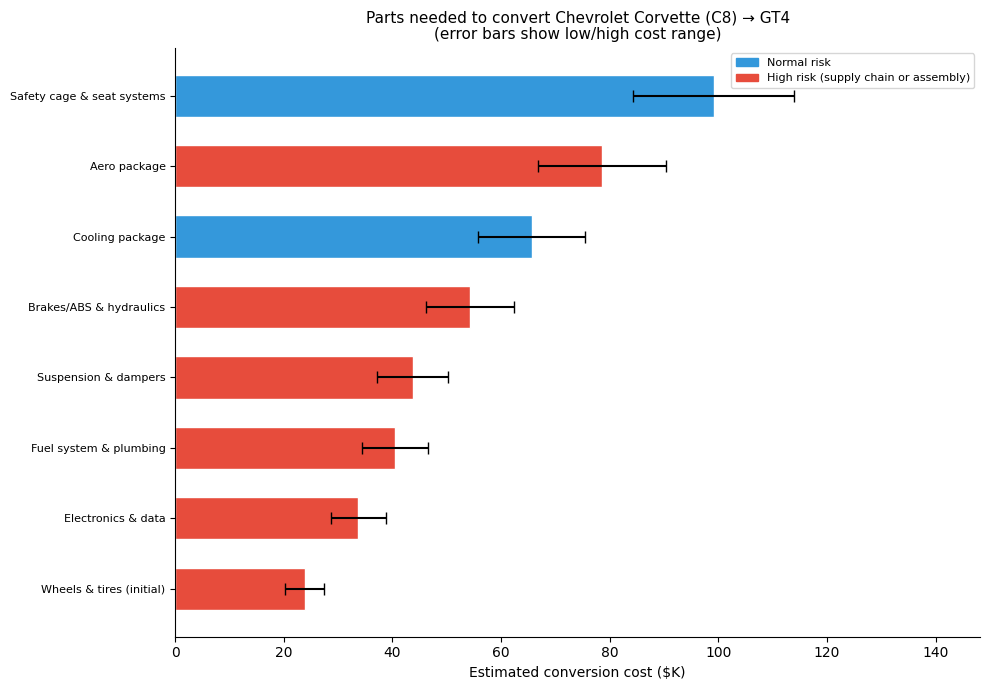


Total conversion cost estimate: $439,341 (12.7x retail MSRP)


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))


bars = ax.barh(
    bom_sorted["subsystem"],
    bom_sorted["cost_mid"] / 1000,
    xerr=[
        (bom_sorted["cost_mid"] - bom_sorted["estimated_cost_low_usd"]) / 1000,
        (bom_sorted["estimated_cost_high_usd"] - bom_sorted["cost_mid"]) / 1000
    ],
    color=bar_colors,
    edgecolor="white",
    capsize=4,
    height=0.6)
ax.set_xlabel("Estimated conversion cost ($K)")
ax.set_title(f"Parts needed to convert {SELECTED_CAR} → {TARGET_CLASS}\n(error bars show low/high cost range)", fontsize=11)
ax.set_xlim(0, bom_sorted["estimated_cost_high_usd"].max() / 1000 * 1.3)
ax.tick_params(axis="y", labelsize=8)
ax.spines[["top", "right"]].set_visible(False)

patches = [
    mpatches.Patch(color="#3498db", label="Normal risk"),
    mpatches.Patch(color="#e74c3c", label="High risk (supply chain or assembly)")]
ax.legend(handles=patches, fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nTotal conversion cost estimate: ${bom_total_mid:,.0f} ({cost_ratio:.1f}x retail MSRP)")

In [ ]:
#predicted price + add delta based on current MSRP!!

#ml part its own section ------> logistic regression (top factors?)



part 3


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

In [ ]:
df_ml["predicted_price"]       = price_model.predict(X)
df_ml["predicted_price_delta"] = df_ml["predicted_price"] - df_ml["msrp_usd"]

In [ ]:
threshold = df_ml["feasibility_score"].median()
df_ml["go_nogo"] = (df_ml["feasibility_score"] >= threshold).astype(int)

print(f"Feasibility score distribution:\n{df_ml['feasibility_score'].describe().round(2)}")
print(f"\nThreshold (median): {threshold:.2f}")
print(f"Class distribution:  GO = {df_ml['go_nogo'].sum()}  |  NO-GO = {(df_ml['go_nogo']==0).sum()}")

Feasibility score distribution:
count    16.00
mean      5.10
std       1.08
min       1.97
25%       4.72
50%       5.07
75%       5.80
max       6.72
Name: feasibility_score, dtype: float64

Threshold (median): 5.07
Class distribution:  GO = 8  |  NO-GO = 8


In [ ]:
# ── features + fit ────────────────────────────────────────────────────────
lr_feature_cols = feature_cols + ["predicted_price_delta"]
X_lr = df_ml[lr_feature_cols]
y_lr = df_ml["go_nogo"]

In [ ]:
print(f"\nUnique classes: {y_lr.unique()}  — shape: {X_lr.shape}")

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr",     LogisticRegression(max_iter=1000, random_state=42, C=1.0))
])
lr_pipeline.fit(X_lr, y_lr)

cv    = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_acc = cross_val_score(lr_pipeline, X_lr, y_lr, cv=cv, scoring="accuracy")
print(f"\nLR accuracy (cross-val): {cv_acc.mean():.3f} ± {cv_acc.std():.3f}")


Unique classes: [0 1]  — shape: (16, 20)

LR accuracy (cross-val): 0.622 ± 0.031


In [ ]:

lr_model = lr_pipeline.named_steps["lr"]
coef_df  = pd.DataFrame({
    "feature":     lr_feature_cols,
    "coefficient": lr_model.coef_[0]
}).sort_values("coefficient", ascending=False)

In [ ]:

print("\nTop factors pushing toward GO (positive):")
print("-" * 55)
for _, row in coef_df[coef_df["coefficient"] > 0].head(5).iterrows():
    bar = "█" * int(abs(row["coefficient"]) * 10)
    print(f"  {row['feature']:<30} {row['coefficient']:>+.3f}  {bar}")


Top factors pushing toward GO (positive):
-------------------------------------------------------
  platform_stability             +0.623  ██████
  cost_ratio                     +0.569  █████
  curb_weight_lb                 +0.548  █████
  breakeven_units                +0.279  ██
  motorsport_heritage            +0.235  ██


In [ ]:
print("\nTop factors pushing toward NO-GO (negative):")
print("-" * 55)
for _, row in coef_df[coef_df["coefficient"] < 0].tail(5).iterrows():
    bar = "█" * int(abs(row["coefficient"]) * 10)
    print(f"  {row['feature']:<30} {row['coefficient']:>+.3f}  {bar}")



Top factors pushing toward NO-GO (negative):
-------------------------------------------------------
  avg_serviceability             -0.346  ███
  annual_spares_rev              -0.346  ███
  avg_assembly_complexity        -0.366  ███
  eng_complexity                 -0.775  ███████
  compliance_risk                -1.158  ███████████


In [ ]:

sel_predicted_price = price_model.predict(sel_features)[0]
sel_delta           = sel_predicted_price - retail_msrp

sel_features_lr = sel_features.copy()
sel_features_lr["predicted_price_delta"] = sel_delta

lr_prob  = lr_pipeline.predict_proba(sel_features_lr)[0]
lr_pred  = lr_pipeline.predict(sel_features_lr)[0]
lr_label = f"GO (score >= {threshold:.2f})" if lr_pred == 1 else f"NO-GO (score < {threshold:.2f})"

In [ ]:

print(f"\nLogistic Regression — {SELECTED_CAR} / {TARGET_CLASS}")
print("-" * 55)
print(f"  Retail MSRP:                 ${retail_msrp:>10,.0f}")
print(f"  Predicted race car price:    ${sel_predicted_price:>10,.0f}")
print(f"  Price delta vs retail:       ${sel_delta:>+10,.0f}  ({sel_delta/retail_msrp*100:+.1f}%)")
print(f"\n  GO probability:              {lr_prob[1]*100:>9.1f}%")
print(f"  NO-GO probability:           {lr_prob[0]*100:>9.1f}%")
print(f"  LR Decision:                 {lr_label}")
print(f"  Rule-based decision:         {verdict}")
print(f"  GBM decision:                {ml_verdict}")
print(f"  (GO/NO-GO split at median feasibility score of {threshold:.2f})")


Logistic Regression — Chevrolet Corvette (C8) / GT4
-------------------------------------------------------
  Retail MSRP:                 $    80,000
  Predicted race car price:    $   281,080
  Price delta vs retail:       $  +201,080  (+251.4%)

  GO probability:                    5.1%
  NO-GO probability:                94.9%
  LR Decision:                 NO-GO (score < 5.07)
  Rule-based decision:         NO-GO
  GBM decision:                NO-GO
  (GO/NO-GO split at median feasibility score of 5.07)


In [ ]:
print("\nLogistic Regression — All Platforms")
print("-" * 85)
print(f"  {'Nameplate':<30} {'Class':<5} {'GO%':>7} {'NO-GO%':>8} {'LR':<20} {'Price Delta':>12}")
print("-" * 85)

for _, row in df_ml.iterrows():
    feats_lr = pd.DataFrame([row[lr_feature_cols]])
    prob     = lr_pipeline.predict_proba(feats_lr)[0]
    pred     = "GO" if lr_pipeline.predict(feats_lr)[0] == 1 else "NO-GO"
    delta    = row["predicted_price_delta"]

    name = df_platforms.loc[
        df_platforms["platform_id"] == row["platform_id"], "nameplate"
    ].values[0]

    print(f"  {name:<30} {row['target_class']:<5} {prob[1]*100:>6.1f}% {prob[0]*100:>7.1f}% {pred:<20} ${delta:>+10,.0f}")


Logistic Regression — All Platforms
-------------------------------------------------------------------------------------
  Nameplate                      Class     GO%   NO-GO% LR                    Price Delta
-------------------------------------------------------------------------------------
  Chevrolet Camaro (Gen6)        GT4     26.8%    73.2% NO-GO                $  +235,515
  Chevrolet Camaro (Gen6)        GT3     74.0%    26.0% GO                   $  +512,105
  Chevrolet Corvette (C8)        GT4      5.1%    94.9% NO-GO                $  +201,080
  Chevrolet Corvette (C8)        GT3     15.0%    85.0% NO-GO                $  +544,034
  Cadillac CT5-V Blackwing       GT4     78.7%    21.3% GO                   $  +149,811
  Cadillac CT5-V Blackwing       GT3     16.1%    83.9% NO-GO                $  +508,357
  Porsche 718 Cayman             GT4     10.9%    89.1% NO-GO                $  +221,419
  Porsche 718 Cayman             GT3      6.7%    93.3% NO-GO                $

In [ ]:
print("\n3-Way Decision Comparison — Rule vs GBM vs Logistic Regression")
print("-" * 75)
print(f"  {'Nameplate':<30} {'Class':<5} {'Rule':<20} {'GBM':<20} {'LR'}")
print("-" * 75)

for _, row in df_ml.iterrows():
    rule_dec = "GO" if row["feasibility_score"] >= 7 else ("GO W/ CONDITIONS" if row["feasibility_score"] >= 5 else "NO-GO")

    feats_gbm = pd.DataFrame([row[feature_cols]])
    gbm_score = feas_model.predict(feats_gbm)[0]
    gbm_dec   = "GO" if gbm_score >= 7 else ("GO W/ CONDITIONS" if gbm_score >= 5 else "NO-GO")

    feats_lr = pd.DataFrame([row[lr_feature_cols]])
    lr_dec   = "GO" if lr_pipeline.predict(feats_lr)[0] == 1 else "NO-GO"

    name = df_platforms.loc[
        df_platforms["platform_id"] == row["platform_id"], "nameplate"
    ].values[0]

    print(f"  {name:<30} {row['target_class']:<5} {rule_dec:<20} {gbm_dec:<20} {lr_dec}")


3-Way Decision Comparison — Rule vs GBM vs Logistic Regression
---------------------------------------------------------------------------
  Nameplate                      Class Rule                 GBM                  LR
---------------------------------------------------------------------------
  Chevrolet Camaro (Gen6)        GT4   NO-GO                NO-GO                NO-GO
  Chevrolet Camaro (Gen6)        GT3   GO W/ CONDITIONS     GO W/ CONDITIONS     GO
  Chevrolet Corvette (C8)        GT4   NO-GO                NO-GO                NO-GO
  Chevrolet Corvette (C8)        GT3   NO-GO                NO-GO                NO-GO
  Cadillac CT5-V Blackwing       GT4   GO W/ CONDITIONS     GO W/ CONDITIONS     GO
  Cadillac CT5-V Blackwing       GT3   NO-GO                NO-GO                NO-GO
  Porsche 718 Cayman             GT4   NO-GO                NO-GO                NO-GO
  Porsche 718 Cayman             GT3   GO W/ CONDITIONS     NO-GO                NO-GO
  Ford Mus

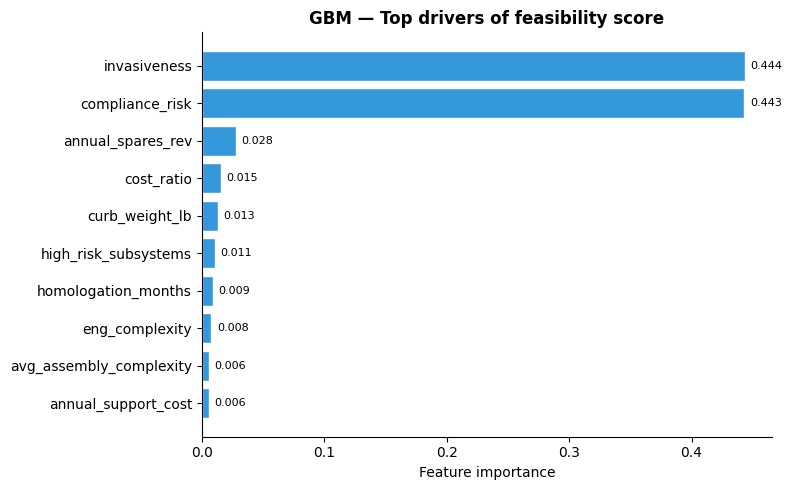

In [ ]:
import matplotlib.pyplot as plt

top_n = 10
imp = importance_df.head(top_n).sort_values("importance")

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(imp["feature"], imp["importance"], color="#3498db", edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=8)
ax.set_xlabel("Feature importance")
ax.set_title("GBM — Top drivers of feasibility score", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

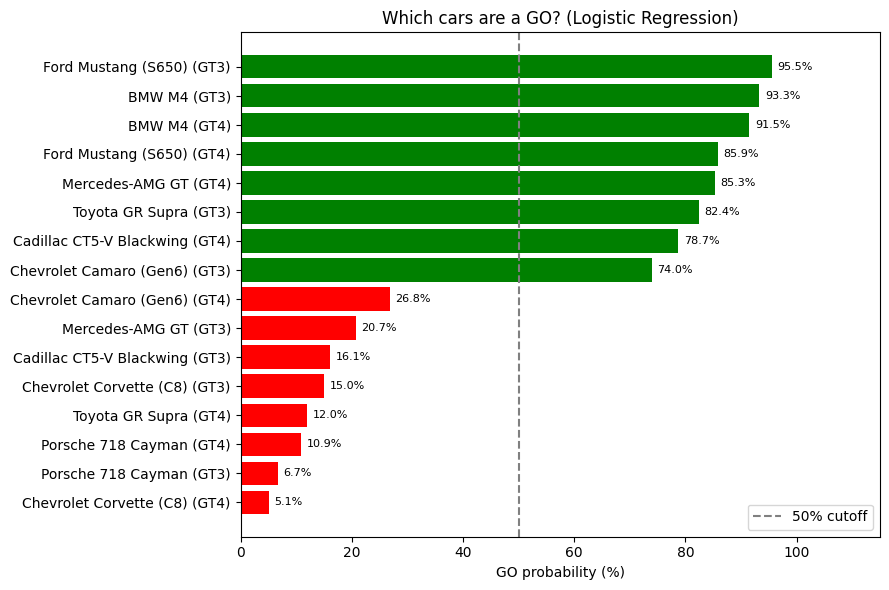

In [ ]:


labels = []
go_probs = []
colors = []

for _, row in df_ml.iterrows():
    feats = pd.DataFrame([row[lr_feature_cols]])
    prob = lr_pipeline.predict_proba(feats)[0][1] * 100
    pred = lr_pipeline.predict(feats)[0]

    name = df_platforms.loc[df_platforms["platform_id"] == row["platform_id"], "nameplate"].values[0]
    labels.append(name + " (" + row["target_class"] + ")")
    go_probs.append(prob)
    colors.append("green" if pred == 1 else "red")

sorted_data = sorted(zip(go_probs, labels, colors))
go_probs, labels, colors = zip(*sorted_data)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(labels, go_probs, color=colors)
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=8)
ax.axvline(50, color="gray", linestyle="--", label="50% cutoff")
ax.set_xlabel("GO probability (%)")
ax.set_title("Which cars are a GO? (Logistic Regression)")
ax.set_xlim(0, 115)
ax.legend()
plt.tight_layout()
plt.show()

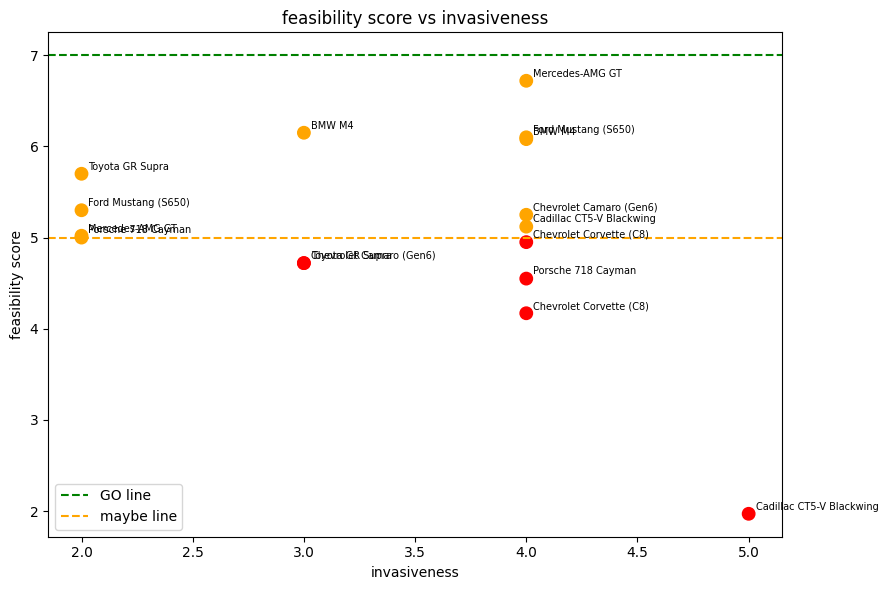

In [ ]:

top_feature = importance_df.iloc[0]["feature"]

colors = []
for score in df_ml["feasibility_score"]:
    if score >= 7:
        colors.append("green")
    elif score >= 5:
        colors.append("orange")
    else:
        colors.append("red")

names = df_ml["platform_id"].map(df_platforms.set_index("platform_id")["nameplate"])

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df_ml[top_feature], df_ml["feasibility_score"], color=colors, s=80)

for x, y, name in zip(df_ml[top_feature], df_ml["feasibility_score"], names):
    ax.annotate(name, (x, y), xytext=(5, 3), textcoords="offset points", fontsize=7)

ax.axhline(7, color="green",  linestyle="--", label="GO line")
ax.axhline(5, color="orange", linestyle="--", label="maybe line")

ax.set_xlabel(top_feature)
ax.set_ylabel("feasibility score")
ax.set_title(f"feasibility score vs {top_feature}")
ax.legend()

plt.tight_layout()
plt.show()